# HSS Analysis: Qwen Math — GMM Matrix Results

This notebook performs a complete post-hoc analysis of the 4-combo GMM
discretization matrix (2 views × 2 preprocessing variants) that was produced
by `run_bundle_gmm_matrix.py`.

**What has already been computed (expensive):**
- `scan` — ICL / silhouette / stability for every (layer, k) pair
- `select` — optimal k per layer via ICL-parsimonious selection
- `discretize` — full GMM clustering + cross-layer alignment → `global_labels`

**What this notebook computes (cheap, seconds each):**
- Preliminary suite (dynamics, information theory, label analysis)
- Prediction (HSS-NB, HSS-Markov vs. continuous baselines)
- Cross-combo comparison
- Custom trajectory pattern analysis

All heavy lifting is already done; everything here runs on a small integer
matrix `global_labels [N, L]` plus pre-computed cluster centers.

## 0. Setup

In [1]:
import sys
import json
import warnings
from pathlib import Path
from dataclasses import replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import TwoSlopeNorm, Normalize
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

### Path configuration

Adjust these two paths to match your machine:

In [2]:
# -- EDIT THESE --
PROJECT_ROOT = Path("/workspace/projects/hidden-states-as-states")
RESULTS_ROOT = Path("/workspace/results/qwen_math_gmm_matrix_k50_reg1e4")

# Add project source to Python path
for p in [PROJECT_ROOT, PROJECT_ROOT / "src"]:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

# Quick sanity check
assert RESULTS_ROOT.exists(), f"Results not found: {RESULTS_ROOT}"
print(f"Project root : {PROJECT_ROOT}")
print(f"Results root : {RESULTS_ROOT}")

Project root : /workspace/projects/hidden-states-as-states
Results root : /workspace/results/qwen_math_gmm_matrix_k50_reg1e4


In [3]:
import hss
from hss_workbench import Workspace
from experiments.config import (
    PredictionConfig, DiscretizeConfig, StabilityConfig,
    ScanConfig, SelectConfig, VisualizationConfig,
)
from experiments.prediction import run_prediction
from experiments.preliminary import run_preliminary_suite
from experiments.information import run_information_analysis, run_effective_rank
from experiments.label_analysis import run_label_analysis, find_sink_states
from experiments.statistics import run_dynamics, run_sequence_stats
from experiments.discretize import run_tolerance_sweep, build_rel_icl_surface
from hss.trajectory import (
    count_transitions, self_transition_prob, active_states_per_layer,
)

print(f"hss version: {hss.__version__}")

hss version: 0.3.0


In [4]:
# Plotting defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.5,
    "font.size": 10,
})
COLORS = {
    "blue": "#2171b5", "orange": "#d94801", "green": "#238b45",
    "red": "#cb181d", "purple": "#6a51a3", "gray": "#636363",
    "cyan": "#0097a7",
}

---
## 1. Matrix Overview — What Do We Have?

In [5]:
# Load the matrix manifest produced by run_bundle_gmm_matrix.py
manifest_path = RESULTS_ROOT / "matrix_manifest.json"
with open(manifest_path) as f:
    matrix_manifest = json.load(f)

combos = []
for entry in matrix_manifest:
    combos.append({
        "view": entry.get("view_name", ""),
        "preprocess": entry.get("preprocess_name", ""),
        "status": entry.get("status", ""),
        "n_items": entry.get("n_items"),
        "n_layers": entry.get("n_layers"),
        "state_dim": entry.get("state_dim"),
        "n_global_states": entry.get("n_global_states"),
        "k_mean": entry.get("k_summary", {}).get("k_mean"),
        "k_min": entry.get("k_summary", {}).get("k_min"),
        "k_max": entry.get("k_summary", {}).get("k_max"),
        "positive_rate": entry.get("positive_rate"),
        "workspace": entry.get("workspace_root", ""),
    })

combo_df = pd.DataFrame(combos)
display(combo_df.drop(columns=["workspace"]))

,view,preprocess,status,n_items,n_layers,state_dim,n_global_states,k_mean,k_min,k_max,positive_rate
0,sample_mean,raw,done,4934,29,3584,136,43.379310,2,50,0.509728
1,sample_mean,standardize,done,4934,29,3584,175,46.172414,40,50,0.509728
2,sample_prompt_last,raw,done,4934,29,3584,153,42.724138,2,50,0.509728
3,sample_prompt_last,standardize,done,4934,29,3584,134,43.137931,2,50,0.509728


In [6]:
# Enumerate workspace directories
COMBO_DIRS = {}
for entry in matrix_manifest:
    if entry.get("status") == "done":
        key = f"{entry['view_name']}__{entry['preprocess_name']}"
        ws_path = Path(entry.get("workspace_root", ""))
        if not ws_path.exists():
            # Try constructing from RESULTS_ROOT
            ws_path = RESULTS_ROOT / f"{entry['view_name']}__{entry['preprocess_name']}__gmm"
        if ws_path.exists():
            COMBO_DIRS[key] = ws_path

print(f"Found {len(COMBO_DIRS)} workspace(s):")
for name, path in COMBO_DIRS.items():
    print(f"  {name:40s} -> {path}")

Found 4 workspace(s):
  sample_mean__raw                         -> /workspace/results/qwen_math_gmm_matrix_k50_reg1e4/sample_mean__raw__gmm
  sample_mean__standardize                 -> /workspace/results/qwen_math_gmm_matrix_k50_reg1e4/sample_mean__standardize__gmm
  sample_prompt_last__raw                  -> /workspace/results/qwen_math_gmm_matrix_k50_reg1e4/sample_prompt_last__raw__gmm
  sample_prompt_last__standardize          -> /workspace/results/qwen_math_gmm_matrix_k50_reg1e4/sample_prompt_last__standardize__gmm


---
## 2. Deep Dive — Pick One Combo

We start by doing a thorough analysis of a single combo, then compare
across all four in Section 5.  By default we pick `sample_mean__standardize`
because standardization is the recommended preprocessing for GMM.

In [7]:
# Pick the primary combo to analyze in depth
PRIMARY_KEY = "sample_mean__standardize"
if PRIMARY_KEY not in COMBO_DIRS:
    PRIMARY_KEY = list(COMBO_DIRS.keys())[0]
    print(f"Fallback to: {PRIMARY_KEY}")

PRIMARY_DIR = COMBO_DIRS[PRIMARY_KEY]
print(f"Primary combo: {PRIMARY_KEY}")
print(f"Workspace dir: {PRIMARY_DIR}")

Primary combo: sample_mean__standardize
Workspace dir: /workspace/results/qwen_math_gmm_matrix_k50_reg1e4/sample_mean__standardize__gmm


In [8]:
ws = Workspace(PRIMARY_DIR, quiet=True, thread_limit=1)
data = ws.open_data()

print(f"N items   : {data.loaded.n_items:,}")
print(f"N layers  : {len(data.layers)}")
print(f"State dim : {data.loaded.state_dim}")
print(f"Layers    : {data.layers}")
print(f"Has labels: {len(data.y) > 0}")
if len(data.y) > 0:
    print(f"Positive rate: {data.y.mean():.4f}  ({data.y.sum():,} / {len(data.y):,})")

N items   : 4,934
N layers  : 29
State dim : 3584
Layers    : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
Has labels: True
Positive rate: 0.5097  (2,515 / 4,934)


### 2.1 Scan Metrics — ICL, Silhouette, Stability across k

In [9]:
scan_art = ws.load_scan("scan")
metrics = scan_art.metrics_df.copy()

print(f"Scan metrics: {len(metrics)} rows")
print(f"Layers scanned: {sorted(metrics['layer'].unique())[:5]} ... ({metrics['layer'].nunique()} total)")
print(f"k range: [{metrics['k'].min()}, {metrics['k'].max()}]")
display(metrics.head(10))

Scan metrics: 1421 rows
Layers scanned: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)] ... (29 total)
k range: [2, 50]


,layer,k,icl,silhouette,stability,n_samples
0,1,2,4.861184e+07,0.079413,0.997835,4934
1,1,3,4.740522e+07,0.042409,1.000000,4934
2,1,4,4.684062e+07,0.043614,0.630434,4934
3,1,5,4.632900e+07,0.032852,0.672944,4934
4,1,6,4.593758e+07,0.051011,0.999765,4934
5,1,7,4.555558e+07,0.046552,0.649465,4934
6,1,8,4.529704e+07,0.051405,0.571531,4934
7,1,9,4.503645e+07,0.035095,0.542363,4934
8,1,10,4.470461e+07,0.037523,0.613865,4934
9,1,11,4.451042e+07,0.037915,0.550807,4934


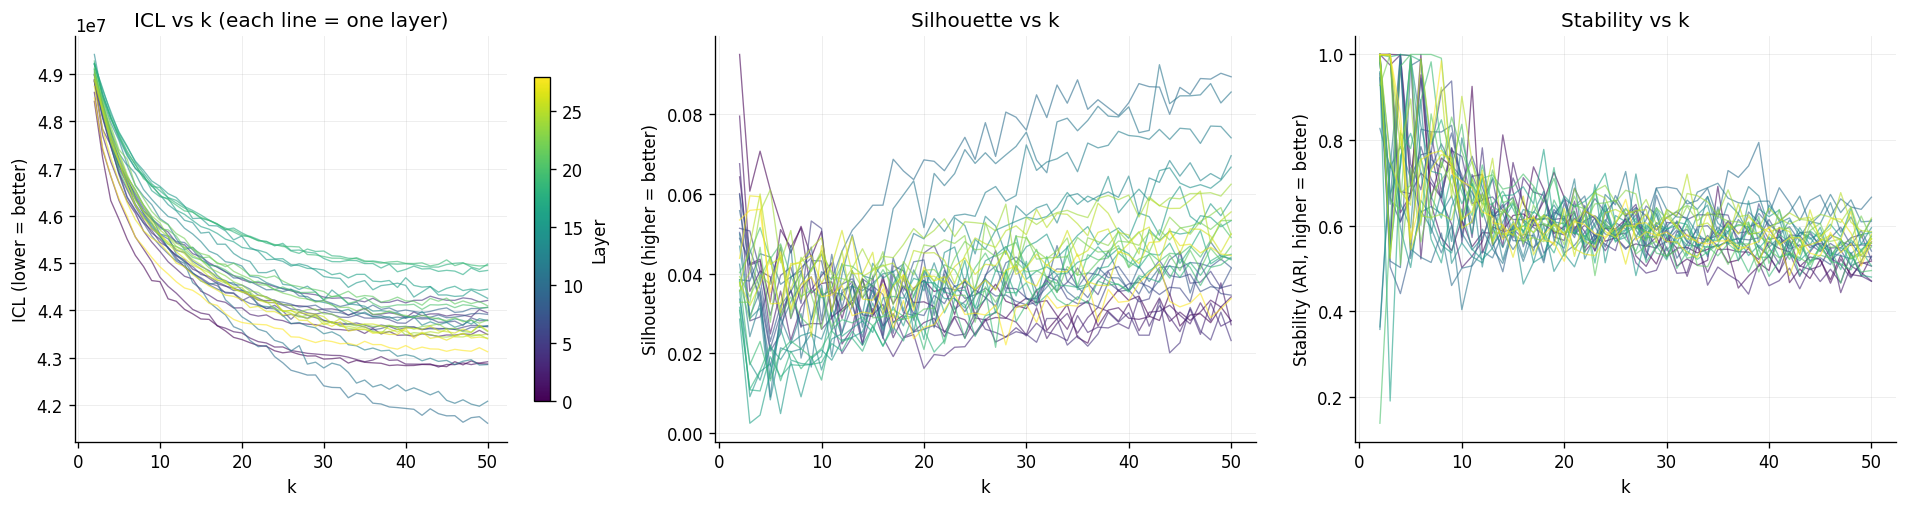

In [10]:
# ICL curves per layer (lower is better)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel 1: ICL vs k, one line per layer
ax = axes[0]
layers_to_show = sorted(metrics["layer"].unique())
n_layers_total = len(layers_to_show)
cmap = plt.cm.viridis
for i, layer in enumerate(layers_to_show):
    sub = metrics[metrics["layer"] == layer].sort_values("k")
    color = cmap(i / max(1, n_layers_total - 1))
    ax.plot(sub["k"], sub["icl"], color=color, alpha=0.6, lw=0.8)
ax.set_xlabel("k")
ax.set_ylabel("ICL (lower = better)")
ax.set_title("ICL vs k (each line = one layer)")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=Normalize(
    vmin=min(layers_to_show), vmax=max(layers_to_show)))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Layer", shrink=0.8)

# Panel 2: Silhouette vs k
ax = axes[1]
for i, layer in enumerate(layers_to_show):
    sub = metrics[metrics["layer"] == layer].sort_values("k")
    color = cmap(i / max(1, n_layers_total - 1))
    ax.plot(sub["k"], sub["silhouette"], color=color, alpha=0.6, lw=0.8)
ax.set_xlabel("k")
ax.set_ylabel("Silhouette (higher = better)")
ax.set_title("Silhouette vs k")

# Panel 3: Stability vs k
ax = axes[2]
for i, layer in enumerate(layers_to_show):
    sub = metrics[metrics["layer"] == layer].sort_values("k")
    if "stability" in sub.columns:
        color = cmap(i / max(1, n_layers_total - 1))
        ax.plot(sub["k"], sub["stability"], color=color, alpha=0.6, lw=0.8)
ax.set_xlabel("k")
ax.set_ylabel("Stability (ARI, higher = better)")
ax.set_title("Stability vs k")

plt.tight_layout()
plt.show()

### 2.2 K Selection — What k Was Chosen Per Layer?

In [11]:
select_art = ws.load_select("select")
k_map = select_art.k_map
ks = np.array(list(k_map.values()))
layers_sorted = sorted(k_map.keys())

print(f"Strategy: {select_art.strategy}")
print(f"k map: {dict(sorted(k_map.items()))}")
print(f"k stats: mean={ks.mean():.1f}, std={ks.std():.1f}, min={ks.min()}, max={ks.max()}")

Strategy: icl_parsimonious
k map: {0: 45, 1: 44, 2: 44, 3: 40, 4: 40, 5: 42, 6: 47, 7: 47, 8: 40, 9: 42, 10: 50, 11: 49, 12: 49, 13: 46, 14: 48, 15: 50, 16: 44, 17: 47, 18: 49, 19: 49, 20: 42, 21: 50, 22: 49, 23: 48, 24: 50, 25: 47, 26: 46, 27: 45, 28: 50}
k stats: mean=46.2, std=3.2, min=40, max=50


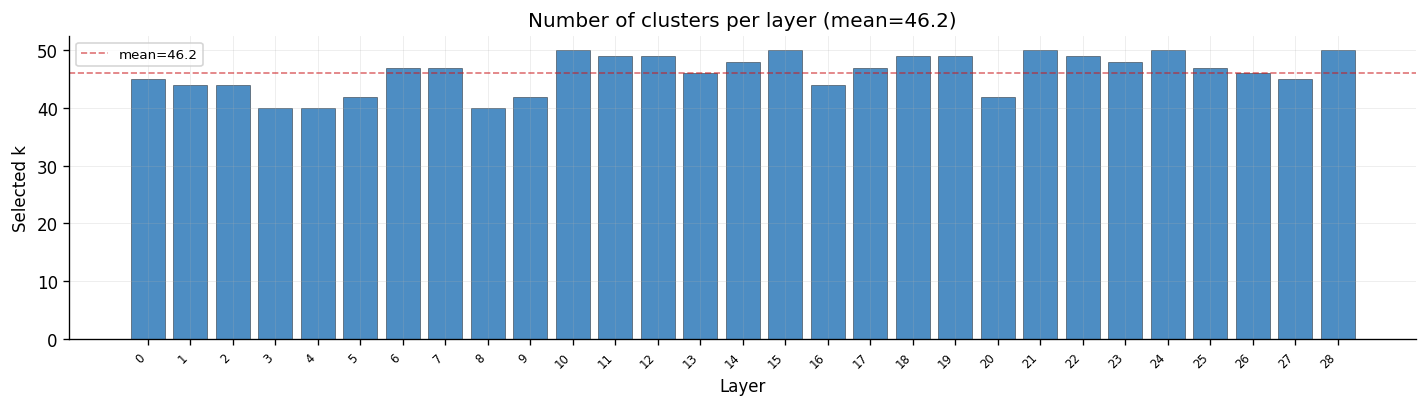

In [12]:
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(range(len(layers_sorted)), [k_map[l] for l in layers_sorted],
       color=COLORS["blue"], alpha=0.8, edgecolor="black", linewidth=0.3)
ax.set_xticks(range(len(layers_sorted)))
ax.set_xticklabels([str(l) for l in layers_sorted], rotation=45, ha="right", fontsize=7)
ax.set_xlabel("Layer")
ax.set_ylabel("Selected k")
ax.set_title(f"Number of clusters per layer (mean={ks.mean():.1f})")
ax.axhline(ks.mean(), color=COLORS["red"], ls="--", lw=1, alpha=0.6, label=f"mean={ks.mean():.1f}")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 2.3 Tolerance Sweep — How Sensitive Is k to the Parsimony Threshold?

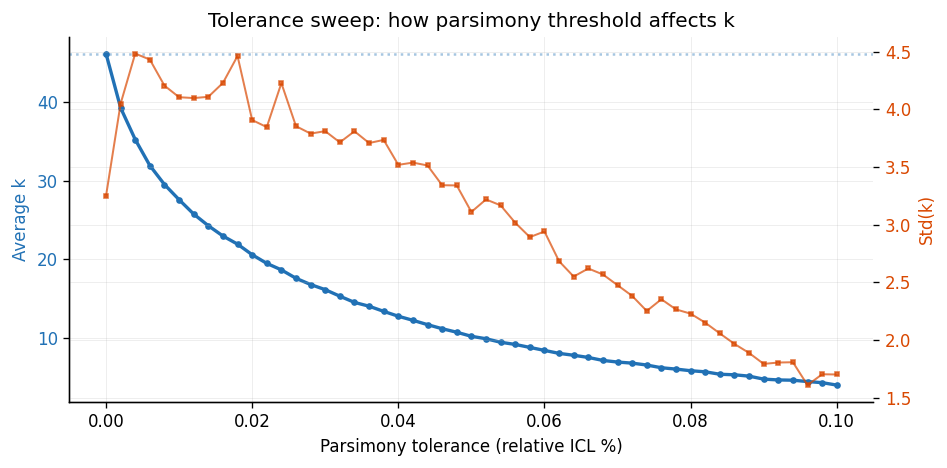

In [13]:
tolerance_df = run_tolerance_sweep(
    metrics, tolerances=np.linspace(0.0, 0.10, 51),
    stability_min=0.3,
)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(tolerance_df["tolerance"], tolerance_df["avg_k"],
         color=COLORS["blue"], lw=2, marker="o", ms=3)
ax1.set_xlabel("Parsimony tolerance (relative ICL %)")
ax1.set_ylabel("Average k", color=COLORS["blue"])
ax1.tick_params(axis="y", labelcolor=COLORS["blue"])
ax1.axhline(ks.mean(), color=COLORS["blue"], ls=":", alpha=0.4)

if "std_k" in tolerance_df.columns:
    ax2 = ax1.twinx()
    ax2.plot(tolerance_df["tolerance"], tolerance_df["std_k"],
             color=COLORS["orange"], lw=1.2, marker="s", ms=2, alpha=0.7)
    ax2.set_ylabel("Std(k)", color=COLORS["orange"])
    ax2.tick_params(axis="y", labelcolor=COLORS["orange"])

ax1.set_title("Tolerance sweep: how parsimony threshold affects k")
plt.tight_layout()
plt.show()

### 2.4 Discretization Summary — Global Labels & Alignment

In [14]:
disc_art = ws.load_discretize("discretize")
gl = np.asarray(disc_art.global_labels)
hss_result = disc_art.hss_result
layers = list(disc_art.layers)

print(f"Global labels shape : {gl.shape}  (N_items x N_layers)")
print(f"N global states     : {disc_art.n_global_states}")
print(f"Effective k map     : {disc_art.k_map}")
print(f"Unique states used  : {len(np.unique(gl[gl >= 0]))}")

Global labels shape : (4934, 29)  (N_items x N_layers)
N global states     : 175
Effective k map     : {0: 45, 1: 44, 10: 50, 11: 49, 12: 49, 13: 46, 14: 48, 15: 50, 16: 44, 17: 47, 18: 49, 19: 49, 2: 44, 20: 42, 21: 50, 22: 49, 23: 48, 24: 50, 25: 47, 26: 46, 27: 45, 28: 50, 3: 40, 4: 40, 5: 42, 6: 47, 7: 47, 8: 40, 9: 42}
Unique states used  : 175


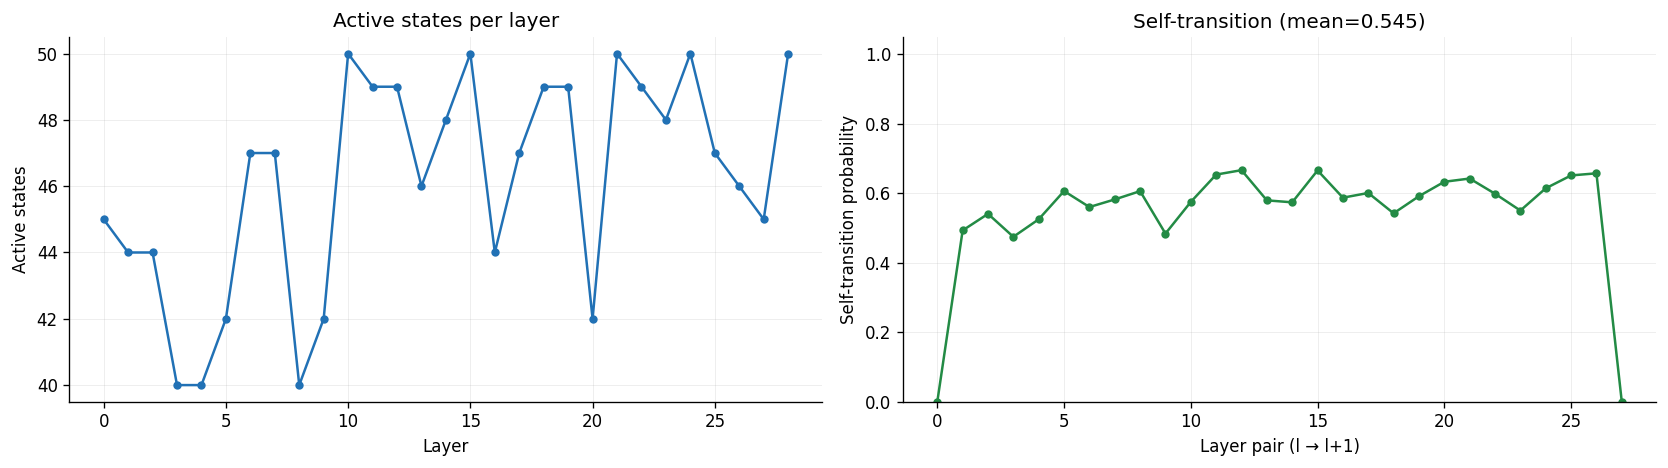

In [15]:
# Active states per layer + self-transition probability
self_trans = self_transition_prob(gl)
active = active_states_per_layer(gl)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(layers, active, marker="o", ms=4, color=COLORS["blue"], lw=1.5)
ax.set_xlabel("Layer")
ax.set_ylabel("Active states")
ax.set_title("Active states per layer")

ax = axes[1]
ax.plot(layers[:-1], self_trans, marker="o", ms=4, color=COLORS["green"], lw=1.5)
ax.set_xlabel("Layer pair (l → l+1)")
ax.set_ylabel("Self-transition probability")
ax.set_title(f"Self-transition (mean={np.nanmean(self_trans):.3f})")
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

### 2.5 Alignment Events — Births and Deaths

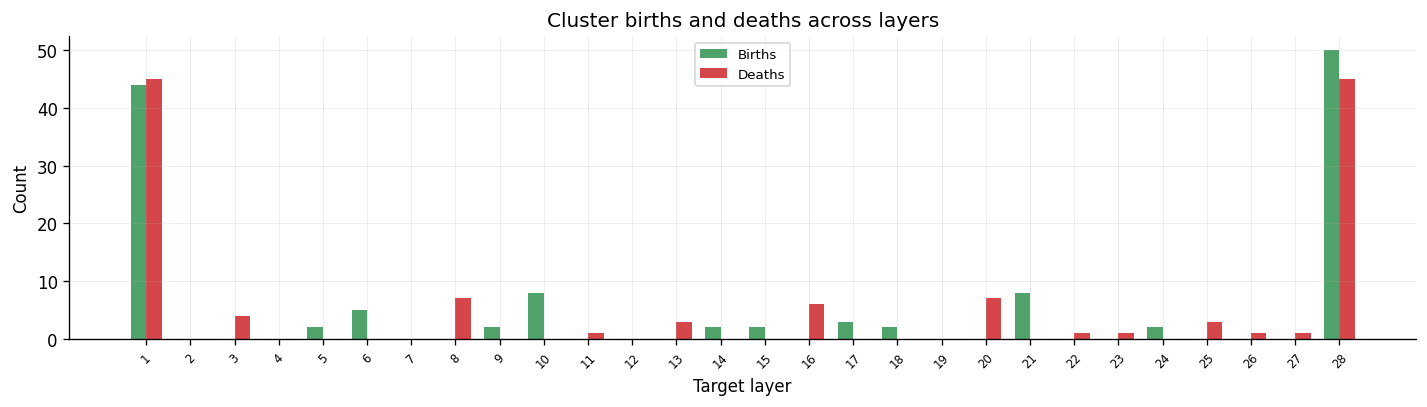

Total births: 130
Total deaths: 125


In [16]:
if hss_result.alignment is not None:
    alignment = hss_result.alignment
    births_per_step = [len(step.births) for step in alignment.steps]
    deaths_per_step = [len(step.deaths) for step in alignment.steps]
    step_layers = [step.layer_to for step in alignment.steps]

    fig, ax = plt.subplots(figsize=(12, 3.5))
    width = 0.35
    x = np.arange(len(step_layers))
    ax.bar(x - width/2, births_per_step, width, label="Births", color=COLORS["green"], alpha=0.8)
    ax.bar(x + width/2, deaths_per_step, width, label="Deaths", color=COLORS["red"], alpha=0.8)
    ax.set_xticks(x[::max(1, len(x)//15)])
    ax.set_xticklabels([str(step_layers[i]) for i in range(0, len(step_layers), max(1, len(x)//15))],
                       rotation=45, fontsize=7)
    ax.set_xlabel("Target layer")
    ax.set_ylabel("Count")
    ax.set_title("Cluster births and deaths across layers")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    print(f"Total births: {sum(births_per_step)}")
    print(f"Total deaths: {sum(deaths_per_step)}")
else:
    print("No alignment (single layer?)")

---
## 3. Preliminary Analysis — Dynamics, Information, Labels

In [ ]:
# Run the full preliminary suite (fast — operates on global_labels + y)
if not ws.store.has_artifact("analysis", "prelim"):
    ws.run_preliminary("prelim", discretize="discretize")
    print("Preliminary analysis completed.")
else:
    print("Preliminary analysis already exists, loading.")

prelim = ws.load_preliminary("prelim")

### 3.1 Dynamics — State Sizes and Flows

In [17]:
node_df = prelim.dynamics.node_df
flow_df = prelim.dynamics.flow_df

print(f"Node table : {len(node_df)} rows (layer × cluster)")
print(f"Flow table : {len(flow_df)} rows (transitions)")
display(node_df.head(10))

NameError: name 'prelim' is not defined

NameError: name 'node_df' is not defined

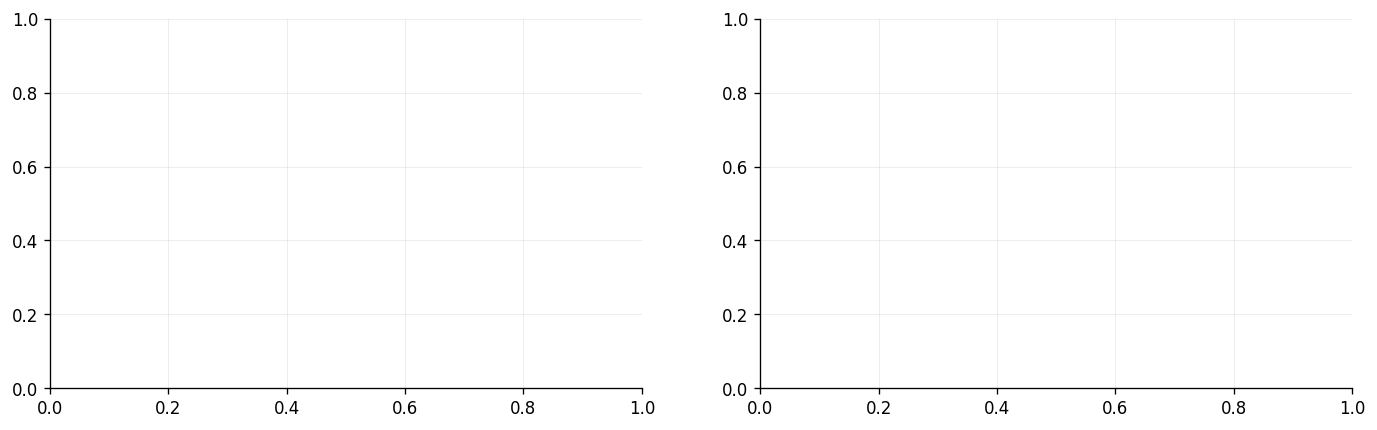

In [18]:
# Distribution of cluster sizes across all layers
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(node_df["count"], bins=50, color=COLORS["blue"], alpha=0.7, edgecolor="black", lw=0.3)
ax.set_xlabel("Cluster size (# items)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of cluster sizes across all layers")
ax.axvline(node_df["count"].median(), color=COLORS["red"], ls="--", lw=1,
           label=f"median={node_df['count'].median():.0f}")
ax.legend(fontsize=8)

# Fraction of items in top-k clusters per layer
ax = axes[1]
for topn in [1, 3, 5]:
    fracs = []
    for layer in layers:
        sub = node_df[node_df["layer"] == layer].sort_values("count", ascending=False)
        total = sub["count"].sum()
        top = sub.head(topn)["count"].sum()
        fracs.append(top / total if total > 0 else 0)
    ax.plot(layers, fracs, marker="o", ms=3, lw=1.2, label=f"Top-{topn}")
ax.set_xlabel("Layer")
ax.set_ylabel("Fraction of items")
ax.set_title("Concentration: fraction of items in largest clusters")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 3.2 Information Theory — Does Discretization Capture Label Info?

In [19]:
y = data.y
if len(y) > 0 and prelim.information is not None:
    info_df = prelim.information.df.copy()
    display(info_df)

    fig, ax1 = plt.subplots(figsize=(10, 4.5))

    c1, c2 = COLORS["blue"], COLORS["red"]
    l1, = ax1.plot(info_df["layer"], info_df["H_C"], marker="o", ms=5,
                   color=c1, lw=1.5, label="$H(C_\\ell)$")
    ax1.set_xlabel("Layer")
    ax1.set_ylabel("$H(C_\\ell)$ (bits)", color=c1)
    ax1.tick_params(axis="y", labelcolor=c1)

    ax2 = ax1.twinx()
    l2, = ax2.plot(info_df["layer"], info_df["I_CY"], marker="s", ms=5,
                   color=c2, lw=1.5, label="$I(C_\\ell; Y)$")
    ax2.set_ylabel("$I(C_\\ell; Y)$ (bits)", color=c2)
    ax2.tick_params(axis="y", labelcolor=c2)

    H_Y = float(info_df["H_Y"].iloc[0])
    ax2.axhline(H_Y, color=c2, ls="--", alpha=0.4, lw=1)
    ax2.text(info_df["layer"].iloc[-1], H_Y * 1.02, f"$H(Y)$={H_Y:.3f}",
             fontsize=8, color=c2, ha="right")

    ax1.legend([l1, l2], [l1.get_label(), l2.get_label()],
               loc="upper left", fontsize=9)
    ax1.set_title("Information curve: cluster entropy vs. mutual information with label")
    plt.tight_layout()
    plt.show()

    # Information bottleneck plane
    fig, ax = plt.subplots(figsize=(6, 5))
    x = info_df["H_C"].values
    yv = info_df["I_CY"].values
    lvals = info_df["layer"].values
    norm = Normalize(vmin=lvals.min(), vmax=lvals.max())
    sc = ax.scatter(x, yv, c=lvals, cmap="viridis", norm=norm,
                    s=50, edgecolors="black", linewidths=0.4, zorder=3)
    ax.plot(x, yv, lw=0.8, alpha=0.4, color="gray", zorder=1)
    for i in range(0, len(x), max(1, len(x) // 8)):
        ax.annotate(f"L{lvals[i]}", (x[i], yv[i]),
                    textcoords="offset points", xytext=(5, 3), fontsize=7)
    ax.set_xlabel("$H(C_\\ell)$ (bits)")
    ax.set_ylabel("$I(C_\\ell; Y)$ (bits)")
    ax.set_title("Information plane")
    plt.colorbar(sc, ax=ax, label="Layer", shrink=0.8)
    plt.tight_layout()
    plt.show()
else:
    print("No binary labels available — skipping information analysis.")

NameError: name 'prelim' is not defined

### 3.3 Label Analysis — Which Clusters Are "Correct" vs. "Incorrect"?

In [20]:
if len(y) > 0 and prelim.label_analysis is not None:
    la = prelim.label_analysis
    print(f"Baseline P(correct) = {la.baseline:.4f}")
    print(f"N global states     = {la.delta_matrix.shape[1]}")
    print(f"Cluster order (by mean delta): {la.cluster_order[:15]} ...")

    # Delta heatmap: P(correct|cluster) - P(correct)
    order = la.cluster_order
    sub = la.delta_matrix[:, order]
    finite = sub[np.isfinite(sub)]
    vmax = max(float(np.nanmax(np.abs(finite))) if finite.size else 0.1, 0.01)

    fig, ax = plt.subplots(figsize=(max(8, len(order) * 0.25), 5))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
    im = ax.imshow(sub, cmap="RdBu_r", norm=norm, aspect="auto", interpolation="nearest")
    ax.set_xlabel("Global Cluster ID (sorted by mean delta)")
    ax.set_ylabel("Layer index")

    n_c = len(order)
    step_x = max(1, n_c // 15)
    ax.set_xticks(range(0, n_c, step_x))
    ax.set_xticklabels([str(order[i]) for i in range(0, n_c, step_x)],
                       rotation=45, ha="right", fontsize=7)
    step_y = max(1, len(layers) // 12)
    ax.set_yticks(range(0, len(layers), step_y))
    ax.set_yticklabels([str(layers[i]) for i in range(0, len(layers), step_y)], fontsize=7)

    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("$P(correct|cluster) - P(correct)$", fontsize=9)
    ax.set_title("Delta heatmap: red = more correct, blue = more incorrect")
    plt.tight_layout()
    plt.show()

    # Top positive and negative clusters
    mean_delta = np.nanmean(la.delta_matrix, axis=0)
    total_count = la.count_matrix.sum(axis=0)
    active_mask = total_count > 0
    gids = np.arange(len(mean_delta))

    top_pos = gids[active_mask][np.argsort(-mean_delta[active_mask])[:10]]
    top_neg = gids[active_mask][np.argsort(mean_delta[active_mask])[:10]]

    print("\nTop 10 POSITIVE clusters (most associated with correct answers):")
    for gid in top_pos:
        print(f"  GID {gid:3d}: delta = {mean_delta[gid]:+.4f}, "
              f"total count = {total_count[gid]:,}")

    print("\nTop 10 NEGATIVE clusters (most associated with incorrect answers):")
    for gid in top_neg:
        print(f"  GID {gid:3d}: delta = {mean_delta[gid]:+.4f}, "
              f"total count = {total_count[gid]:,}")

    # Sink states
    sinks = prelim.sink_states
    if len(sinks) > 0:
        print(f"\nSink states ({len(sinks)} found):")
        display(sinks)
    else:
        print("\nNo sink states found with default criteria.")
else:
    print("No labels — skipping label analysis.")

NameError: name 'prelim' is not defined

### 3.4 Sequence Statistics

In [21]:
seq = prelim.sequence_stats
print(f"Self-transition mean : {seq.self_trans_mean:.4f}")
print(f"Active states mean   : {seq.active_mean:.1f}")
print(f"Marginal freq shape  : {seq.marginal_freq.shape}")

# Marginal frequency distribution
fig, ax = plt.subplots(figsize=(8, 3.5))
freq = seq.marginal_freq
freq_nz = freq[freq > 0]
ax.bar(range(len(freq_nz)), np.sort(freq_nz)[::-1],
       color=COLORS["blue"], alpha=0.7, edgecolor="black", lw=0.2)
ax.set_xlabel("Global state (sorted by frequency)")
ax.set_ylabel("Marginal frequency")
ax.set_title(f"State frequency distribution ({len(freq_nz)} active states)")
plt.tight_layout()
plt.show()

NameError: name 'prelim' is not defined

---
## 4. Prediction — Can Discrete Trajectories Predict Correctness?

In [22]:
if len(y) > 0:
    pred_cfg = PredictionConfig(
        n_splits=5,
        seed=42,
        alpha=1.0,
        methods=["HSS-NB", "HSS-Markov", "GaussianNB", "Logistic"],
        continuous_feature_mode="last_layer",
        continuous_standardize=True,
    )

    if not ws.store.has_artifact("analysis", "pred"):
        print("Running prediction (5-fold CV)...")
        ws.run_prediction("pred", discretize="discretize", config=pred_cfg)
        print("Done.")
    else:
        print("Prediction already exists, loading.")

    pred = ws.load_prediction("pred")
    print("\n=== Prediction Summary ===")
    display(pred.summary_df)
    print()
    display(pred.fold_df.groupby("method")[["auroc", "accuracy", "f1"]].describe().round(4))
else:
    pred = None
    print("No labels — skipping prediction.")

Running prediction (5-fold CV)...
Done.

=== Prediction Summary ===


,method,mean_auroc,std_auroc,mean_accuracy,std_accuracy,mean_f1,std_f1
0,HSS-NB,0.789169,0.018432,0.709155,0.016524,0.714180,0.018117
1,HSS-Markov,0.797052,0.021147,0.722531,0.019721,0.733790,0.018458
2,GaussianNB,0.750773,0.019623,0.730234,0.017404,0.746984,0.019160
3,Logistic,0.807817,0.007217,0.733889,0.010672,0.739379,0.011750


auroc                                                          \
           count    mean     std     min     25%     50%     75%     max   
method                                                                     
GaussianNB   5.0  0.7508  0.0196  0.7255  0.7346  0.7583  0.7656  0.7699   
HSS-Markov   5.0  0.7971  0.0211  0.7636  0.7945  0.8022  0.8035  0.8215   
HSS-NB       5.0  0.7892  0.0184  0.7608  0.7820  0.7972  0.7973  0.8085   
Logistic     5.0  0.8078  0.0072  0.7974  0.8045  0.8103  0.8103  0.8166   

           accuracy          ...                    f1                  \
              count    mean  ...     75%     max count    mean     std   
method                       ...                                         
GaussianNB      5.0  0.7302  ...  0.7396  0.7487   5.0  0.7470  0.0192   
HSS-Markov      5.0  0.7225  ...  0.7264  0.7467   5.0  0.7338  0.0185   
HSS-NB          5.0  0.7092  ...  0.7194  0.7214   5.0  0.7142  0.0181   
Logistic        5.0  0.7339  ...  0.7444  0.7447   5.0  0.7394  0.0118   

                                                   
               min    25%     50%     75%     max  
method                                             
GaussianNB  0.7197  0.739  0.7490  0.7564  0.7708  
HSS-Markov  0.7077  0.730  0.7321  0.7405  0.7587  
HSS-NB      0.6853  0.712  0.7149  0.7269  0.7318  
Logistic    0.7247  0.733  0.7367  0.7490  0.7534  

[4 rows x 24 columns]

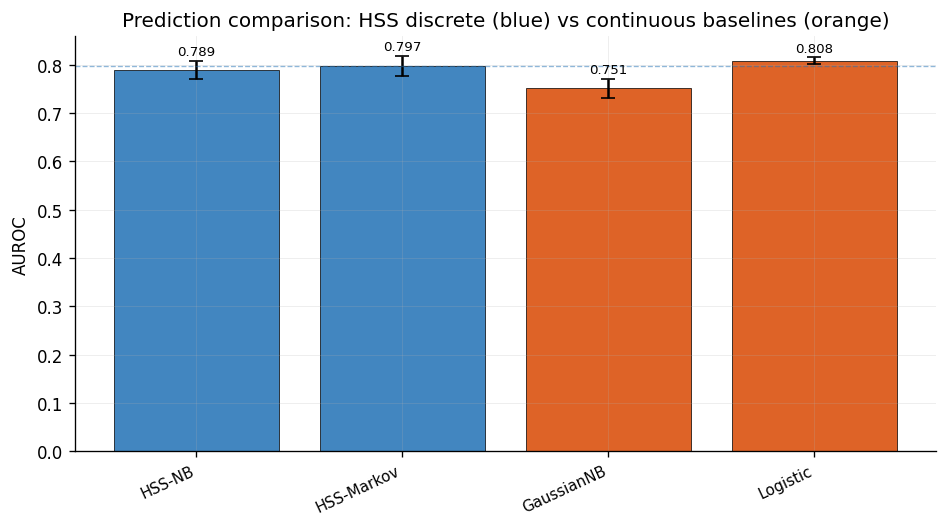

In [23]:
if pred is not None and len(pred.summary_df) > 0:
    summary = pred.summary_df.copy()
    methods = summary["method"].tolist()
    x = np.arange(len(methods))
    means = summary["mean_auroc"].values
    stds = summary["std_auroc"].values

    # Color coding: HSS methods vs continuous baselines
    colors = []
    for m in methods:
        if m.startswith("HSS"):
            colors.append(COLORS["blue"])
        else:
            colors.append(COLORS["orange"])

    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.bar(x, means, yerr=stds, color=colors, alpha=0.85,
                  edgecolor="black", linewidth=0.5, capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=25, ha="right", fontsize=9)
    ax.set_ylabel("AUROC")
    ax.set_title("Prediction comparison: HSS discrete (blue) vs continuous baselines (orange)")

    # Annotate values
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(i, m + s + 0.005, f"{m:.3f}", ha="center", va="bottom", fontsize=8)

    # Reference line at best HSS
    hss_mask = [m.startswith("HSS") for m in methods]
    if any(hss_mask):
        best_hss = max(means[i] for i, h in enumerate(hss_mask) if h)
        ax.axhline(best_hss, color=COLORS["blue"], ls="--", lw=0.8, alpha=0.5)

    plt.tight_layout()
    plt.show()

### 4.1 Progressive Prefix Prediction — How Many Layers Do We Need?

Running progressive prefix prediction (15 prefixes)...
Done.


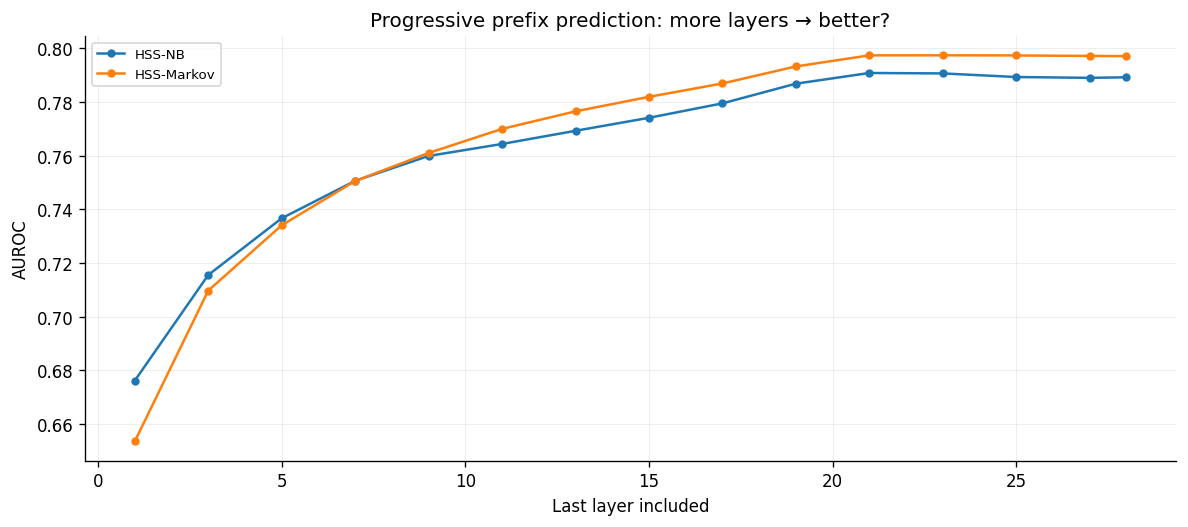

In [24]:
if len(y) > 0 and np.unique(y).shape[0] >= 2:
    # Run prediction with increasing number of layers
    prefix_step = max(1, len(layers) // 10)  # ~10 data points
    prefix_records = []

    prefix_cfg = PredictionConfig(
        n_splits=5, seed=42, alpha=1.0,
        methods=["HSS-NB", "HSS-Markov"],
    )

    prefixes = list(range(max(1, prefix_step), len(layers) + 1, prefix_step))
    if prefixes[-1] != len(layers):
        prefixes.append(len(layers))

    print(f"Running progressive prefix prediction ({len(prefixes)} prefixes)...")
    for plen in prefixes:
        gl_prefix = gl[:, :plen]
        layers_prefix = layers[:plen]
        result = run_prediction(
            data.loaded.provider, gl_prefix, y, layers_prefix,
            prefix_cfg, store=None,
        )
        for _, row in result.summary_df.iterrows():
            prefix_records.append({
                "prefix_len": plen,
                "last_layer": layers_prefix[-1],
                "method": row["method"],
                "mean_auroc": row.get("mean_auroc", np.nan),
            })

    prefix_df = pd.DataFrame(prefix_records)
    print("Done.")

    fig, ax = plt.subplots(figsize=(10, 4.5))
    for method in prefix_df["method"].unique():
        sub = prefix_df[prefix_df["method"] == method]
        ax.plot(sub["last_layer"], sub["mean_auroc"],
                marker="o", ms=4, lw=1.5, label=method)
    ax.set_xlabel("Last layer included")
    ax.set_ylabel("AUROC")
    ax.set_title("Progressive prefix prediction: more layers → better?")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping prefix prediction (no valid labels).")

---
## 5. Cross-Combo Comparison

Now we compare all 4 combos (2 views × 2 preprocessings) on the same
metrics. This answers:
- Does `sample_mean` vs `sample_prompt_last` matter?
- Does standardization help?

In [25]:
cross_records = []

for combo_key, combo_dir in COMBO_DIRS.items():
    try:
        _ws = Workspace(combo_dir, quiet=True, thread_limit=1)
        _data = _ws.open_data()
        _disc = _ws.load_discretize("discretize")
        _select = _ws.load_select("select")
        _gl = np.asarray(_disc.global_labels)
        _y = _data.y
        _layers = list(_disc.layers)
        _ks = np.array(list(_select.k_map.values()))

        # Basic stats
        rec = {
            "combo": combo_key,
            "n_items": _data.loaded.n_items,
            "n_layers": len(_layers),
            "n_global_states": _disc.n_global_states,
            "k_mean": _ks.mean(),
            "k_std": _ks.std(),
            "self_trans_mean": float(np.nanmean(self_transition_prob(_gl))),
            "active_states_mean": float(active_states_per_layer(_gl).mean()),
        }

        # Information (if labels exist)
        if len(_y) > 0:
            from experiments.information import _entropy_bits, _mutual_information_bits
            # Quick MI at last layer
            last_col = _gl[:, -1]
            valid = last_col >= 0
            mi_last = _mutual_information_bits(last_col[valid], _y[valid])
            rec["MI_last_layer"] = mi_last

            # Quick MI at best layer
            best_mi = 0.0
            best_layer = _layers[0]
            for li in range(len(_layers)):
                col = _gl[:, li]
                v = col >= 0
                mi = _mutual_information_bits(col[v], _y[v])
                if mi > best_mi:
                    best_mi = mi
                    best_layer = _layers[li]
            rec["MI_best"] = best_mi
            rec["MI_best_layer"] = best_layer

        # Prediction (run if not exists)
        pred_cfg_cross = PredictionConfig(
            n_splits=5, seed=42, methods=["HSS-NB", "HSS-Markov"],
        )
        pred_name = "pred_cross"
        if not _ws.store.has_artifact("analysis", pred_name):
            _ws.run_prediction(pred_name, discretize="discretize", config=pred_cfg_cross)
        _pred = _ws.load_prediction(pred_name)

        for _, row in _pred.summary_df.iterrows():
            rec[f"auroc_{row['method']}"] = row.get("mean_auroc", np.nan)

        cross_records.append(rec)
        print(f"  ✓ {combo_key}")
    except Exception as e:
        print(f"  ✗ {combo_key}: {e}")

cross_df = pd.DataFrame(cross_records)
display(cross_df.round(4))

  ✓ sample_mean__raw
  ✓ sample_mean__standardize
  ✓ sample_prompt_last__raw
  ✓ sample_prompt_last__standardize


,combo,n_items,n_layers,n_global_states,k_mean,k_std,self_trans_mean,active_states_mean,MI_last_layer,MI_best,MI_best_layer,auroc_HSS-NB,auroc_HSS-Markov
0,sample_mean__raw,4934,29,136,43.3793,8.9536,0.5525,43.3793,0.1639,0.2220,21,0.7981,0.8052
1,sample_mean__standardize,4934,29,175,46.1724,3.2491,0.5449,46.1724,0.1626,0.2146,19,0.7892,0.7971
2,sample_prompt_last__raw,4934,29,153,42.7241,8.6219,0.4691,42.6897,0.1272,0.1813,18,0.7807,0.7861
3,sample_prompt_last__standardize,4934,29,134,43.1379,9.0353,0.4697,43.1034,0.1318,0.1776,18,0.7809,0.7868


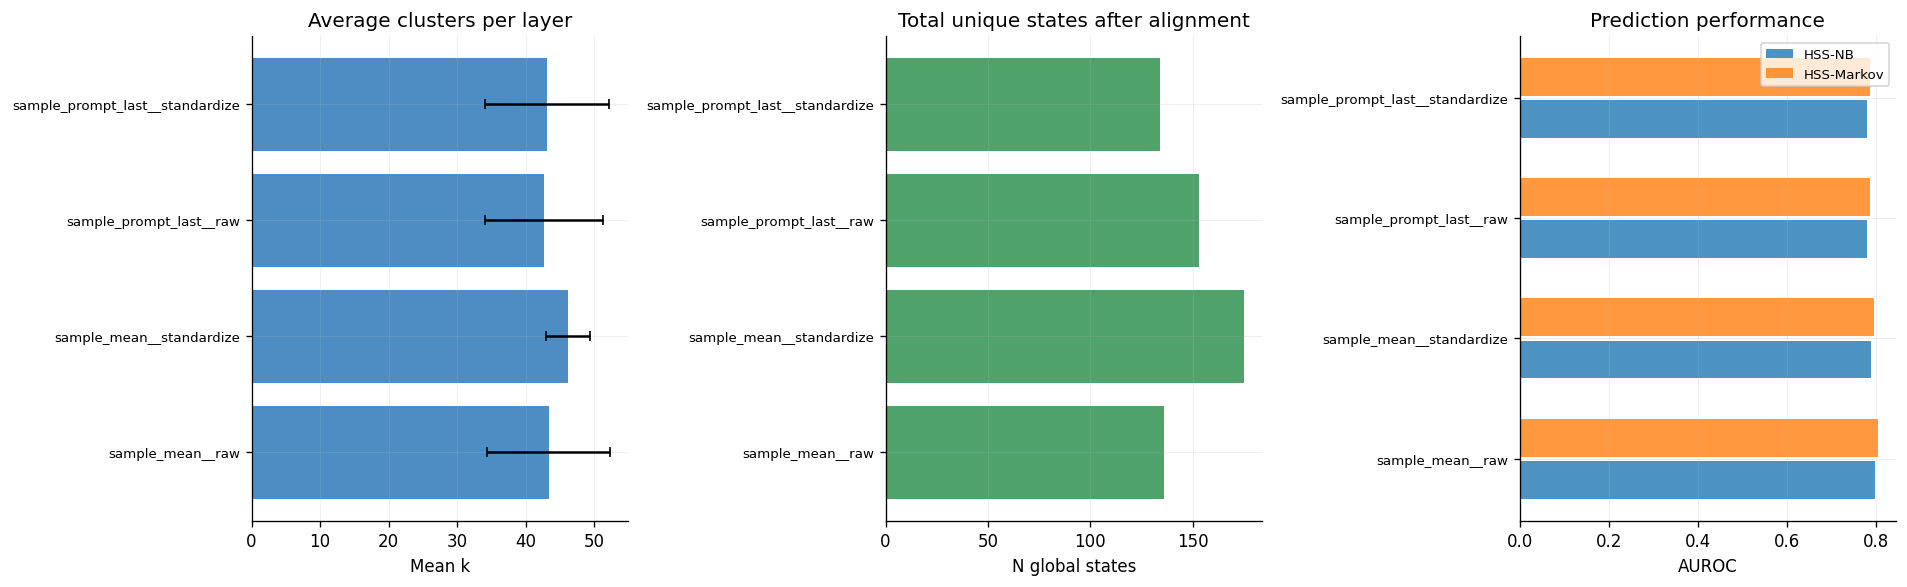

In [26]:
if len(cross_df) > 1:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Panel 1: k_mean comparison
    ax = axes[0]
    x = range(len(cross_df))
    ax.barh(x, cross_df["k_mean"], xerr=cross_df["k_std"],
            color=COLORS["blue"], alpha=0.8, capsize=3)
    ax.set_yticks(x)
    ax.set_yticklabels(cross_df["combo"], fontsize=8)
    ax.set_xlabel("Mean k")
    ax.set_title("Average clusters per layer")

    # Panel 2: n_global_states comparison
    ax = axes[1]
    ax.barh(x, cross_df["n_global_states"], color=COLORS["green"], alpha=0.8)
    ax.set_yticks(x)
    ax.set_yticklabels(cross_df["combo"], fontsize=8)
    ax.set_xlabel("N global states")
    ax.set_title("Total unique states after alignment")

    # Panel 3: AUROC comparison
    ax = axes[2]
    auroc_cols = [c for c in cross_df.columns if c.startswith("auroc_")]
    width = 0.35
    for i, col in enumerate(auroc_cols):
        method = col.replace("auroc_", "")
        offset = (i - len(auroc_cols) / 2 + 0.5) * width
        ax.barh([j + offset for j in x], cross_df[col],
                height=width * 0.9, alpha=0.8,
                label=method)
    ax.set_yticks(x)
    ax.set_yticklabels(cross_df["combo"], fontsize=8)
    ax.set_xlabel("AUROC")
    ax.set_title("Prediction performance")
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

### 5.1 Cross-Combo Information Curves

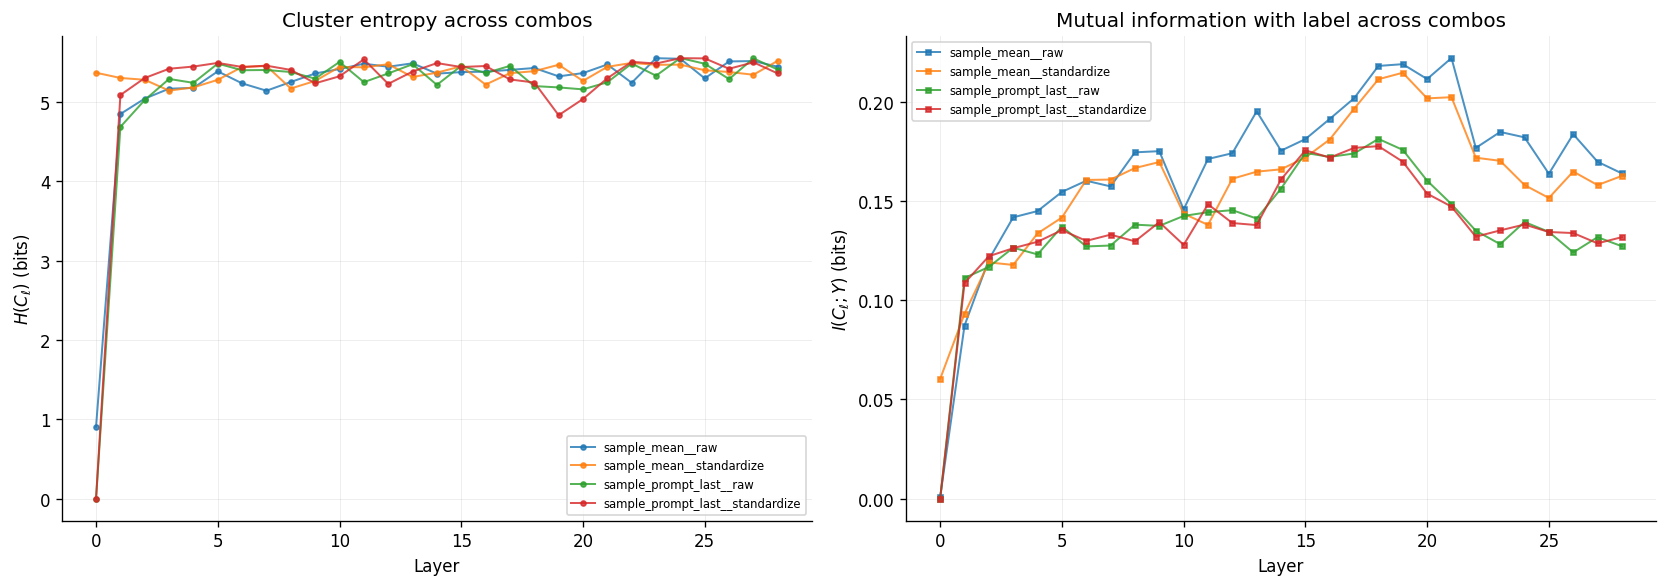

In [27]:
if len(y) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for combo_key, combo_dir in COMBO_DIRS.items():
        try:
            _ws = Workspace(combo_dir, quiet=True, thread_limit=1)
            _data = _ws.open_data()
            _disc = _ws.load_discretize("discretize")
            _gl = np.asarray(_disc.global_labels)
            _y = _data.y
            _layers = list(_disc.layers)

            if len(_y) == 0:
                continue

            from experiments.information import _entropy_bits, _mutual_information_bits
            h_c_vals, mi_vals = [], []
            for li in range(len(_layers)):
                col = _gl[:, li]
                v = col >= 0
                c_counts = np.bincount(col[v])
                h_c_vals.append(_entropy_bits(c_counts))
                mi_vals.append(_mutual_information_bits(col[v], _y[v]))

            axes[0].plot(_layers, h_c_vals, marker="o", ms=3, lw=1.2,
                         label=combo_key, alpha=0.8)
            axes[1].plot(_layers, mi_vals, marker="s", ms=3, lw=1.2,
                         label=combo_key, alpha=0.8)
        except Exception:
            pass

    axes[0].set_xlabel("Layer")
    axes[0].set_ylabel("$H(C_\\ell)$ (bits)")
    axes[0].set_title("Cluster entropy across combos")
    axes[0].legend(fontsize=7)

    axes[1].set_xlabel("Layer")
    axes[1].set_ylabel("$I(C_\\ell; Y)$ (bits)")
    axes[1].set_title("Mutual information with label across combos")
    axes[1].legend(fontsize=7)

    plt.tight_layout()
    plt.show()

---
## 6. Trajectory Pattern Analysis

Custom analysis: what are the most common state trajectories,
and how do they relate to correctness?

In [28]:
# Encode each sample's trajectory as a string
traj_strs = ["_".join(str(x) for x in row) for row in gl]
traj_series = pd.Series(traj_strs)
traj_counts = traj_series.value_counts()

print(f"Total unique trajectories: {len(traj_counts):,}")
print(f"Top trajectory covers {traj_counts.iloc[0]:,} / {len(gl):,} "
      f"= {traj_counts.iloc[0]/len(gl):.1%} of items")
print(f"Top 10 trajectories cover {traj_counts.head(10).sum():,} / {len(gl):,} "
      f"= {traj_counts.head(10).sum()/len(gl):.1%} of items")

Total unique trajectories: 4,096
Top trajectory covers 35 / 4,934 = 0.7% of items
Top 10 trajectories cover 202 / 4,934 = 4.1% of items


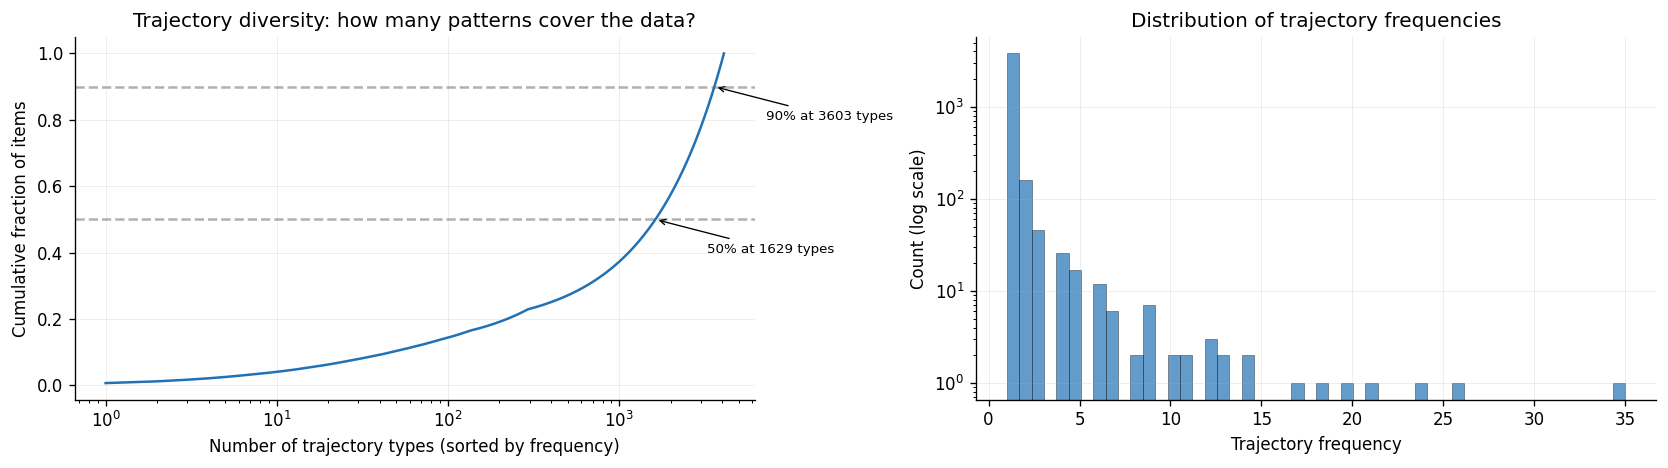

In [29]:
# Trajectory diversity curve
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
cumfrac = np.cumsum(traj_counts.values) / len(gl)
ax.plot(range(1, len(cumfrac) + 1), cumfrac, color=COLORS["blue"], lw=1.5)
ax.set_xlabel("Number of trajectory types (sorted by frequency)")
ax.set_ylabel("Cumulative fraction of items")
ax.set_title("Trajectory diversity: how many patterns cover the data?")
ax.axhline(0.5, color=COLORS["gray"], ls="--", alpha=0.5)
ax.axhline(0.9, color=COLORS["gray"], ls="--", alpha=0.5)
ax.set_xscale("log")
n_50 = int(np.searchsorted(cumfrac, 0.5) + 1)
n_90 = int(np.searchsorted(cumfrac, 0.9) + 1)
ax.annotate(f"50% at {n_50} types", xy=(n_50, 0.5), fontsize=8,
            xytext=(n_50 * 2, 0.4), arrowprops=dict(arrowstyle="->", lw=0.8))
ax.annotate(f"90% at {n_90} types", xy=(n_90, 0.9), fontsize=8,
            xytext=(n_90 * 2, 0.8), arrowprops=dict(arrowstyle="->", lw=0.8))

# Trajectory length vs frequency
ax = axes[1]
ax.hist(traj_counts.values, bins=50, color=COLORS["blue"], alpha=0.7,
        edgecolor="black", lw=0.3, log=True)
ax.set_xlabel("Trajectory frequency")
ax.set_ylabel("Count (log scale)")
ax.set_title("Distribution of trajectory frequencies")

plt.tight_layout()
plt.show()

,trajectory,count,pct,pos_rate,delta,n_unique_states,n_transitions
0,17_47_47_47_47_90_90_90_62_62_62_62_62_62_62_6...,35,0.7094,0.0857,-0.4240,5,4
1,9_50_50_72_72_72_75_94_94_94_94_94_94_94_94_94...,26,0.5270,0.6538,0.1441,6,7
2,36_55_55_55_65_65_65_65_65_65_65_65_65_65_65_6...,24,0.4864,0.8750,0.3653,4,3
3,43_83_83_83_83_83_83_83_83_83_83_83_83_83_83_8...,21,0.4256,0.0476,-0.4621,3,2
4,24_60_60_60_60_60_60_60_60_60_60_60_60_60_60_6...,20,0.4054,0.9500,0.4403,5,4
5,36_55_55_55_65_65_65_65_65_65_65_65_65_65_65_6...,18,0.3648,1.0000,0.4903,5,5
6,27_82_82_82_82_86_86_86_86_86_86_86_86_55_86_8...,17,0.3445,0.8824,0.3726,6,8
7,30_84_86_86_51_51_51_51_51_51_51_51_51_51_51_6...,14,0.2837,1.0000,0.4903,9,10
8,39_68_68_68_67_67_67_67_67_67_74_74_74_74_53_5...,14,0.2837,1.0000,0.4903,7,7
9,9_50_50_72_72_72_75_94_94_94_94_94_94_94_94_94...,13,0.2635,0.7692,0.2595,7,7


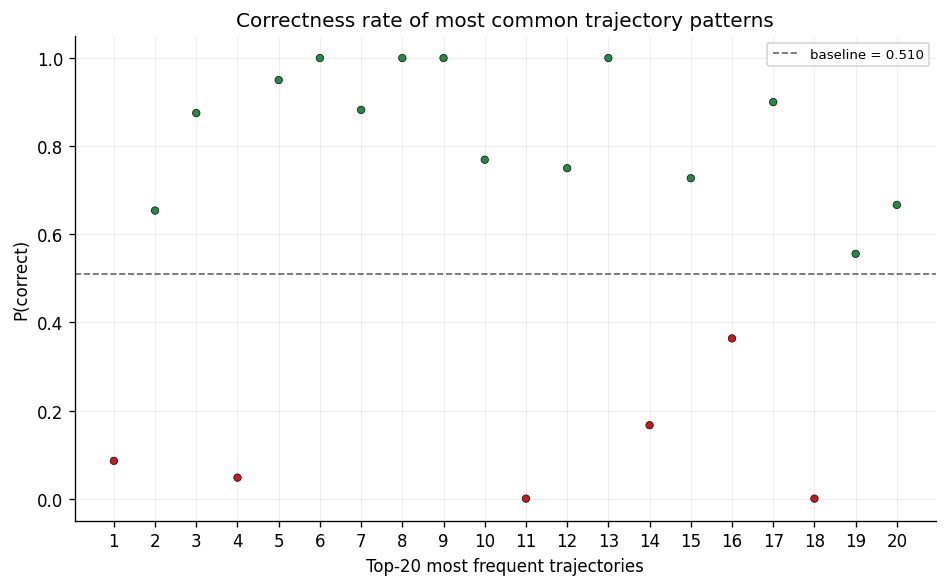

In [30]:
# Top trajectories and their correctness rates
if len(y) > 0:
    top_n = 20
    top_trajs = traj_counts.head(top_n)

    records = []
    for traj_str, count in top_trajs.items():
        mask = np.array([t == traj_str for t in traj_strs])
        pos_rate = float(y[mask].mean())
        # Count unique states in this trajectory
        states = [int(x) for x in traj_str.split("_")]
        n_unique = len(set(states))
        n_changes = sum(1 for i in range(len(states)-1) if states[i] != states[i+1])
        records.append({
            "trajectory": traj_str[:60] + ("..." if len(traj_str) > 60 else ""),
            "count": count,
            "pct": count / len(gl) * 100,
            "pos_rate": pos_rate,
            "delta": pos_rate - float(y.mean()),
            "n_unique_states": n_unique,
            "n_transitions": n_changes,
        })

    top_df = pd.DataFrame(records)
    display(top_df.round(4))

    # Scatter: trajectory frequency vs correctness
    fig, ax = plt.subplots(figsize=(8, 5))
    baseline = float(y.mean())
    colors_scatter = [COLORS["green"] if r["delta"] > 0 else COLORS["red"]
                      for r in records]
    sizes = [max(20, r["count"] / 5) for r in records]
    ax.scatter(range(top_n), [r["pos_rate"] for r in records],
               c=colors_scatter, s=sizes, edgecolors="black", linewidths=0.4, zorder=3)
    ax.axhline(baseline, color="black", ls="--", lw=1, alpha=0.6,
               label=f"baseline = {baseline:.3f}")
    ax.set_xticks(range(top_n))
    ax.set_xticklabels(range(1, top_n + 1))
    ax.set_xlabel(f"Top-{top_n} most frequent trajectories")
    ax.set_ylabel("P(correct)")
    ax.set_title("Correctness rate of most common trajectory patterns")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

### 6.1 Trajectory Stability — Do Nearby Layers Agree?

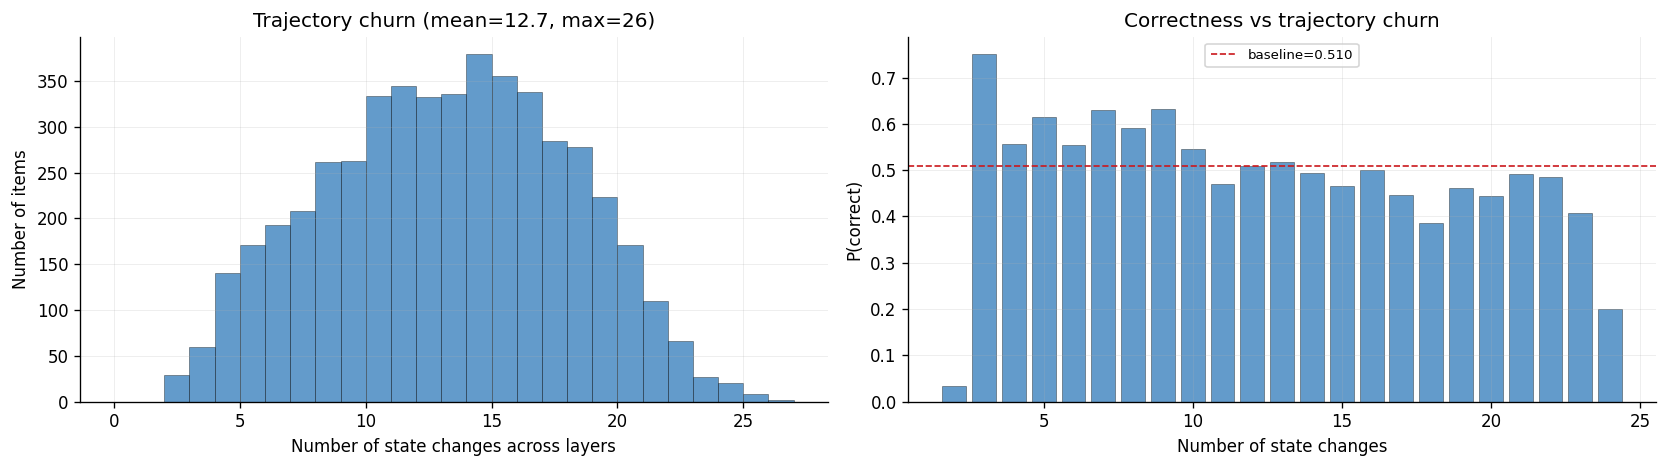

In [31]:
# Per-item "churn": how many times does the global state change?
n_changes = np.sum(gl[:, 1:] != gl[:, :-1], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(n_changes, bins=range(0, int(n_changes.max()) + 2),
        color=COLORS["blue"], alpha=0.7, edgecolor="black", lw=0.3)
ax.set_xlabel("Number of state changes across layers")
ax.set_ylabel("Number of items")
ax.set_title(f"Trajectory churn (mean={n_changes.mean():.1f}, max={n_changes.max()})")

if len(y) > 0:
    ax = axes[1]
    # Bin by churn level and compute correctness
    max_churn = min(int(n_changes.max()), 30)
    churn_bins = range(0, max_churn + 1)
    churn_rates = []
    churn_counts = []
    for c in churn_bins:
        mask = n_changes == c
        if mask.sum() > 10:
            churn_rates.append(float(y[mask].mean()))
            churn_counts.append(int(mask.sum()))
        else:
            churn_rates.append(np.nan)
            churn_counts.append(0)
    ax.bar(list(churn_bins), churn_rates, color=COLORS["blue"], alpha=0.7,
           edgecolor="black", lw=0.3)
    ax.axhline(float(y.mean()), color=COLORS["red"], ls="--", lw=1,
               label=f"baseline={y.mean():.3f}")
    ax.set_xlabel("Number of state changes")
    ax.set_ylabel("P(correct)")
    ax.set_title("Correctness vs trajectory churn")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 7. Relative ICL Surface — The Landscape of k Choices

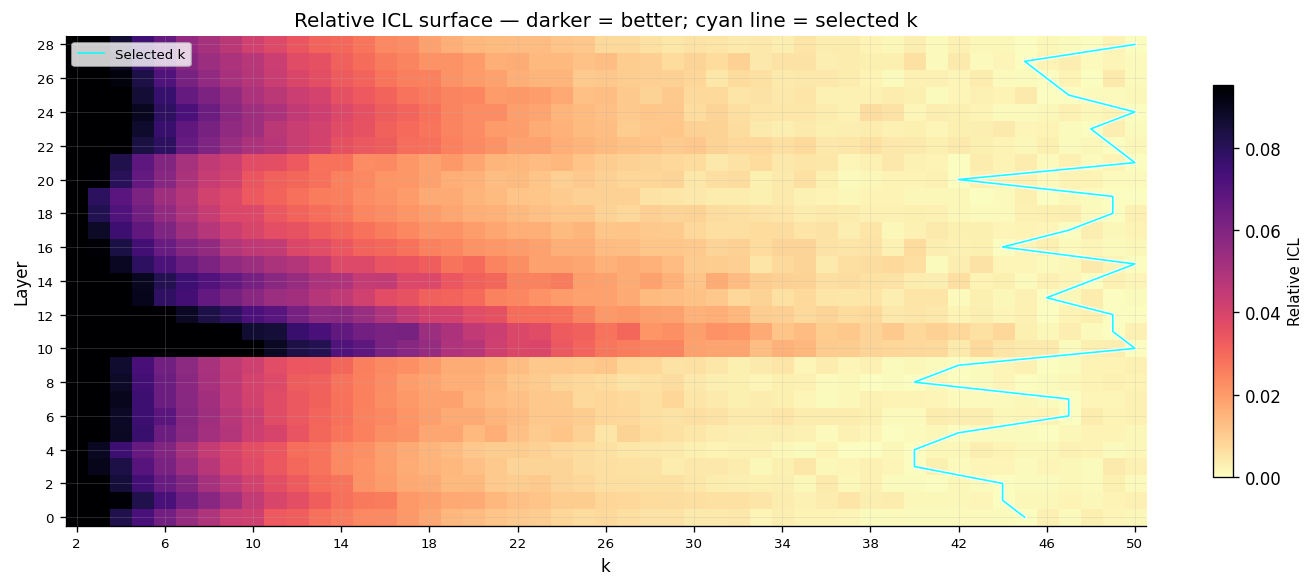

In [32]:
rel_mat, rel_layers, rel_k = build_rel_icl_surface(metrics)

fig, ax = plt.subplots(figsize=(12, 5))
finite = rel_mat[np.isfinite(rel_mat)]
vmax = max(float(np.quantile(finite, 0.95)) if finite.size else 0.2, 0.05)
im = ax.imshow(rel_mat, aspect="auto", interpolation="nearest",
               cmap="magma_r", vmin=0.0, vmax=vmax, origin="lower")
ax.set_xlabel("k")
ax.set_ylabel("Layer")

K = len(rel_k)
L = len(rel_layers)
k_step = max(1, K // 10)
ax.set_xticks(range(0, K, k_step))
ax.set_xticklabels([str(rel_k[j]) for j in range(0, K, k_step)], fontsize=8)
l_step = max(1, L // 10)
ax.set_yticks(range(0, L, l_step))
ax.set_yticklabels([str(int(rel_layers[i])) for i in range(0, L, l_step)], fontsize=8)

# Overlay selected k path
k_to_j = {int(k): j for j, k in enumerate(rel_k)}
xs, ys = [], []
for i, layer in enumerate(rel_layers):
    ks_sel = k_map.get(int(layer))
    j = k_to_j.get(int(ks_sel)) if ks_sel is not None else None
    if j is not None:
        xs.append(j)
        ys.append(i)
if xs:
    ax.plot(xs, ys, color="white", lw=2.5, alpha=0.9, zorder=5)
    ax.plot(xs, ys, color="cyan", lw=1.0, alpha=0.9, zorder=6, label="Selected k")
    ax.legend(fontsize=8)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Relative ICL", fontsize=9)
ax.set_title("Relative ICL surface — darker = better; cyan line = selected k")
plt.tight_layout()
plt.show()

---
## 8. Summary Table

In [33]:
print("=" * 70)
print("ANALYSIS SUMMARY")
print("=" * 70)
print(f"Primary combo       : {PRIMARY_KEY}")
print(f"N items             : {data.loaded.n_items:,}")
print(f"N layers            : {len(layers)}")
print(f"Hidden dim          : {data.loaded.state_dim}")
print(f"N global states     : {disc_art.n_global_states}")
print(f"Mean k              : {ks.mean():.1f} ± {ks.std():.1f}")
print(f"Self-transition mean: {np.nanmean(self_trans):.4f}")
print(f"Unique trajectories : {len(traj_counts):,}")
print(f"50% coverage at     : {n_50} trajectory types")

if len(y) > 0:
    print(f"Positive rate       : {y.mean():.4f}")
    if prelim.information is not None:
        best_mi_row = prelim.information.df.loc[prelim.information.df["I_CY"].idxmax()]
        print(f"Best MI layer       : {int(best_mi_row['layer'])} "
              f"(I={best_mi_row['I_CY']:.4f} bits)")
    if pred is not None and len(pred.summary_df) > 0:
        best_pred = pred.summary_df.loc[pred.summary_df["mean_auroc"].idxmax()]
        print(f"Best predictor      : {best_pred['method']} "
              f"(AUROC={best_pred['mean_auroc']:.4f})")

if len(cross_df) > 1:
    print(f"\n--- Cross-combo comparison ---")
    best_combo = cross_df.loc[cross_df.get("auroc_HSS-NB", cross_df.iloc[:, -1]).idxmax()]
    print(f"Best combo          : {best_combo['combo']}")

print("=" * 70)
print("Done. All results are saved in each workspace's analysis directory.")

ANALYSIS SUMMARY
Primary combo       : sample_mean__standardize
N items             : 4,934
N layers            : 29
Hidden dim          : 3584
N global states     : 175
Mean k              : 46.2 ± 3.2
Self-transition mean: 0.5449
Unique trajectories : 4,096
50% coverage at     : 1629 trajectory types
Positive rate       : 0.5097


NameError: name 'prelim' is not defined

---
## Appendix: How to Re-run Specific Analyses

```python
# Re-run prediction with different methods
ws.run_prediction("pred_v2", discretize="discretize",
    config=PredictionConfig(methods=["HSS-NB", "HSS-Markov", "MLP"]),
    overwrite=True)

# Run stability analysis (slower — re-fits GMM multiple times)
ws.run_stability("stab_v1", discretize="discretize",
    discretize_config=DiscretizeConfig(method="gmm"),
    stability_config=StabilityConfig(seeds=[42,43,44]),
    overwrite=True)

# Run ablation (alignment strategy comparison)
from experiments.config import AblationConfig
ws.run_ablation("ablation_v1", discretize="discretize",
    ablation_config=AblationConfig(
        enabled=["cosine_vs_euclidean", "threshold_sweep", "alignment"]),
    overwrite=True)

# Custom analysis with any function
def my_func(global_labels, y, layers, store):
    # ... your code here ...
    store.save_json("result/my_output.json", {"key": "value"})
    return result

ws.run_analysis("custom_v1", func=my_func, discretize="discretize")
```

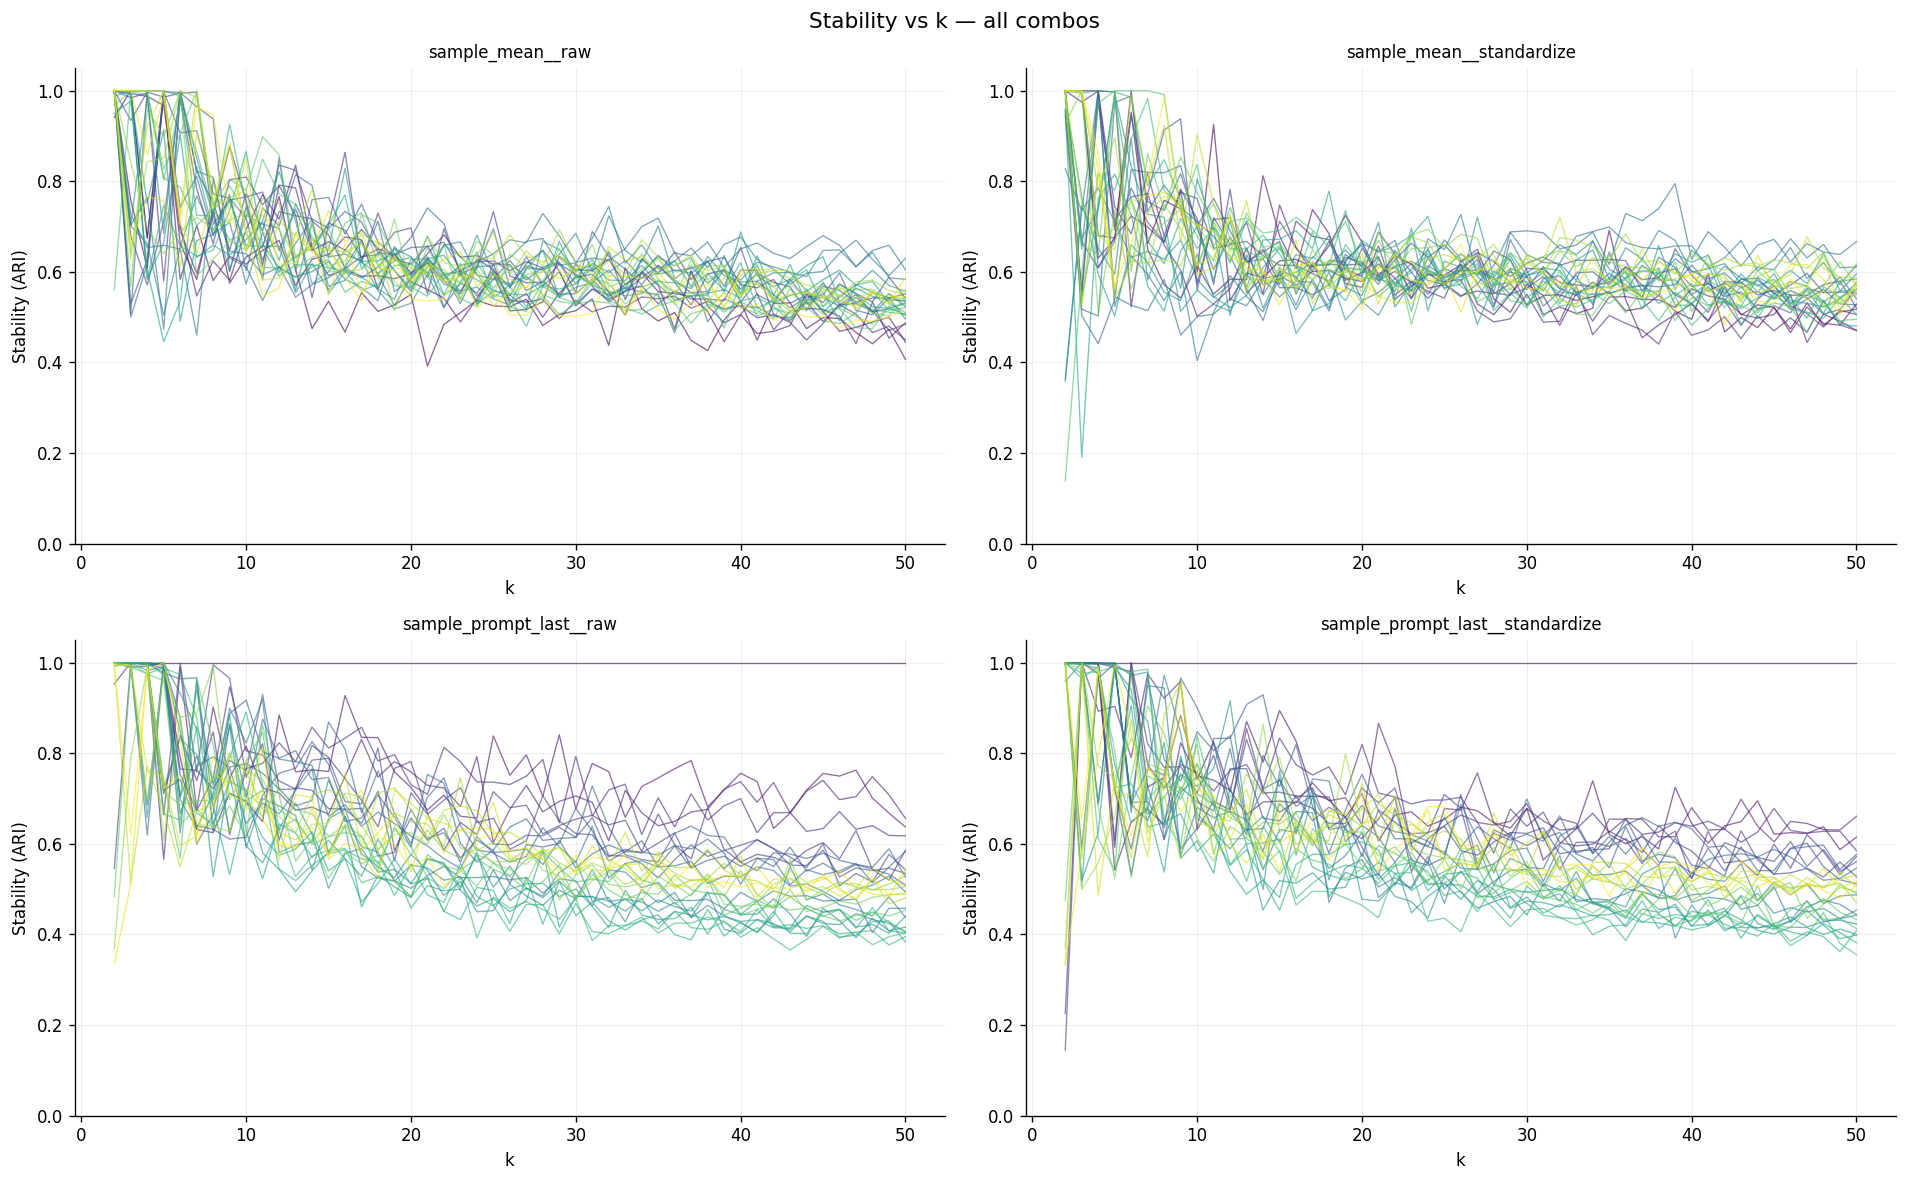

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (combo_key, combo_dir) in enumerate(COMBO_DIRS.items()):
    ax = axes[idx]
    _ws = Workspace(combo_dir, quiet=True, thread_limit=1)
    _scan = _ws.load_scan("scan")
    _metrics = _scan.metrics_df.copy()
    
    layers_all = sorted(_metrics["layer"].unique())
    cmap = plt.cm.viridis
    n_layers = len(layers_all)
    
    for i, layer in enumerate(layers_all):
        sub = _metrics[_metrics["layer"] == layer].sort_values("k")
        if "stability" in sub.columns:
            color = cmap(i / max(1, n_layers - 1))
            ax.plot(sub["k"], sub["stability"], color=color, alpha=0.6, lw=0.8)
    
    ax.set_xlabel("k")
    ax.set_ylabel("Stability (ARI)")
    ax.set_title(combo_key, fontsize=10)
    ax.set_ylim(0, 1.05)

plt.suptitle("Stability vs k — all combos", fontsize=13)
plt.tight_layout()
plt.show()

Correct: 2515, Incorrect: 2419


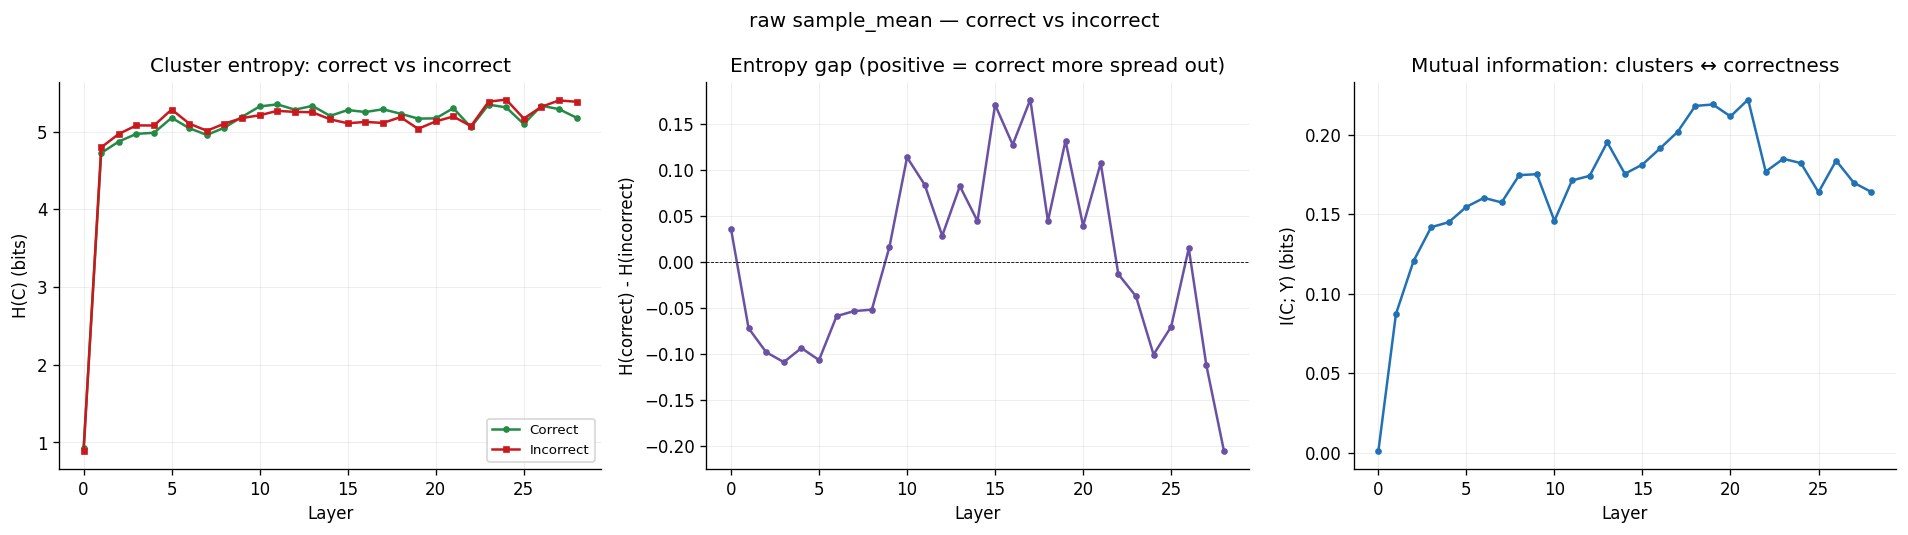


Per-cluster correctness rate (last layer):
  GID  88: n=  199, P(correct)=0.523, delta=+0.013    
  GID  89: n=  140, P(correct)=0.586, delta=+0.076    
  GID  90: n=   73, P(correct)=0.041, delta=-0.469 ---
  GID  91: n=  116, P(correct)=0.629, delta=+0.120 +++
  GID  92: n=  129, P(correct)=0.636, delta=+0.126 +++
  GID  93: n=  151, P(correct)=0.344, delta=-0.165 ---
  GID  94: n=   70, P(correct)=0.329, delta=-0.181 ---
  GID  95: n=   98, P(correct)=0.480, delta=-0.030    
  GID  96: n=  112, P(correct)=0.473, delta=-0.037    
  GID  97: n=  117, P(correct)=0.299, delta=-0.211 ---
  GID  98: n=   92, P(correct)=0.304, delta=-0.205 ---
  GID  99: n=   73, P(correct)=0.233, delta=-0.277 ---
  GID 100: n=  180, P(correct)=0.722, delta=+0.212 +++
  GID 101: n=   47, P(correct)=0.574, delta=+0.065    
  GID 102: n=   23, P(correct)=0.000, delta=-0.510 ---
  GID 103: n=  108, P(correct)=0.889, delta=+0.379 +++
  GID 104: n=   54, P(correct)=0.167, delta=-0.343 ---
  GID 105: n=  147, P

In [36]:
# Use the raw sample_mean combo
raw_dir = COMBO_DIRS.get("sample_mean__raw")
if raw_dir is None:
    raw_dir = list(COMBO_DIRS.values())[0]
    print(f"Fallback: {raw_dir}")

_ws = Workspace(raw_dir, quiet=True, thread_limit=1)
_data = _ws.open_data()
_disc = _ws.load_discretize("discretize")
_gl = np.asarray(_disc.global_labels)
_y = _data.y
_layers = list(_disc.layers)

correct_mask = _y == 1
incorrect_mask = _y == 0

print(f"Correct: {correct_mask.sum()}, Incorrect: {incorrect_mask.sum()}")

# Per-layer: compare cluster distributions between correct and incorrect
from experiments.information import _entropy_bits, _mutual_information_bits

records = []
for li in range(len(_layers)):
    col = _gl[:, li]
    
    # Correct subset
    c_correct = col[correct_mask]
    c_correct = c_correct[c_correct >= 0]
    h_correct = _entropy_bits(np.bincount(c_correct)) if len(c_correct) > 0 else 0
    
    # Incorrect subset
    c_incorrect = col[incorrect_mask]
    c_incorrect = c_incorrect[c_incorrect >= 0]
    h_incorrect = _entropy_bits(np.bincount(c_incorrect)) if len(c_incorrect) > 0 else 0
    
    # Full
    c_all = col[col >= 0]
    mi = _mutual_information_bits(col[col >= 0], _y[col >= 0])
    
    records.append({
        "layer": _layers[li],
        "H_correct": h_correct,
        "H_incorrect": h_incorrect,
        "H_diff": h_correct - h_incorrect,
        "I_CY": mi,
    })

info_split_df = pd.DataFrame(records)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel 1: Entropy of correct vs incorrect
ax = axes[0]
ax.plot(info_split_df["layer"], info_split_df["H_correct"],
        marker="o", ms=3, color=COLORS["green"], label="Correct")
ax.plot(info_split_df["layer"], info_split_df["H_incorrect"],
        marker="s", ms=3, color=COLORS["red"], label="Incorrect")
ax.set_xlabel("Layer")
ax.set_ylabel("H(C) (bits)")
ax.set_title("Cluster entropy: correct vs incorrect")
ax.legend(fontsize=8)

# Panel 2: Entropy difference
ax = axes[1]
ax.plot(info_split_df["layer"], info_split_df["H_diff"],
        marker="o", ms=3, color=COLORS["purple"])
ax.axhline(0, color="black", ls="--", lw=0.5)
ax.set_xlabel("Layer")
ax.set_ylabel("H(correct) - H(incorrect)")
ax.set_title("Entropy gap (positive = correct more spread out)")

# Panel 3: Mutual information
ax = axes[2]
ax.plot(info_split_df["layer"], info_split_df["I_CY"],
        marker="o", ms=3, color=COLORS["blue"])
ax.set_xlabel("Layer")
ax.set_ylabel("I(C; Y) (bits)")
ax.set_title("Mutual information: clusters ↔ correctness")

plt.suptitle("raw sample_mean — correct vs incorrect", fontsize=12)
plt.tight_layout()
plt.show()

# Bonus: top clusters that distinguish correct from incorrect
print("\nPer-cluster correctness rate (last layer):")
last_col = _gl[:, -1]
for gid in np.unique(last_col[last_col >= 0]):
    mask = last_col == gid
    n = mask.sum()
    if n < 20:
        continue
    rate = _y[mask].mean()
    delta = rate - _y.mean()
    marker = "+++" if delta > 0.1 else "---" if delta < -0.1 else "   "
    print(f"  GID {gid:3d}: n={n:5d}, P(correct)={rate:.3f}, delta={delta:+.3f} {marker}")

Total rows: 1257


,layer,gid,n,pos_rate,delta
0,0,0,3343,0.497457,-0.012271
1,0,1,1591,0.535512,0.025784
2,1,2,71,0.704225,0.194497
3,1,3,65,0.492308,-0.017421
4,1,4,45,0.377778,-0.131951
5,1,5,82,0.426829,-0.082899
6,1,6,88,0.579545,0.069817
7,1,7,216,0.518519,0.008790
8,1,8,144,0.381944,-0.127784
9,1,9,199,0.507538,-0.002191


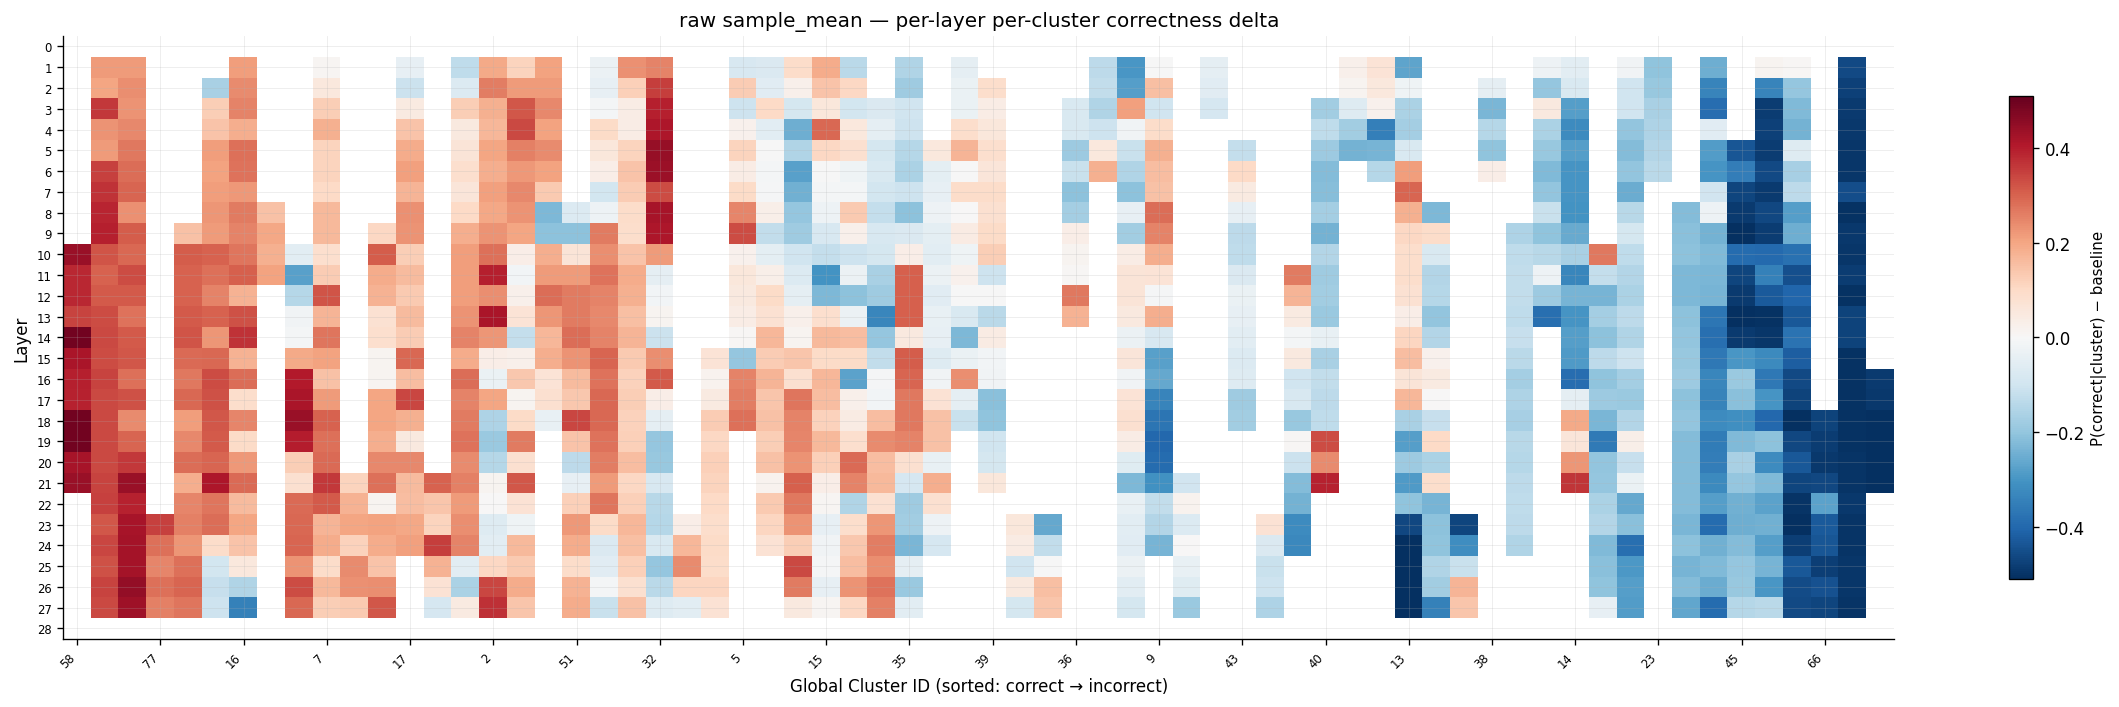

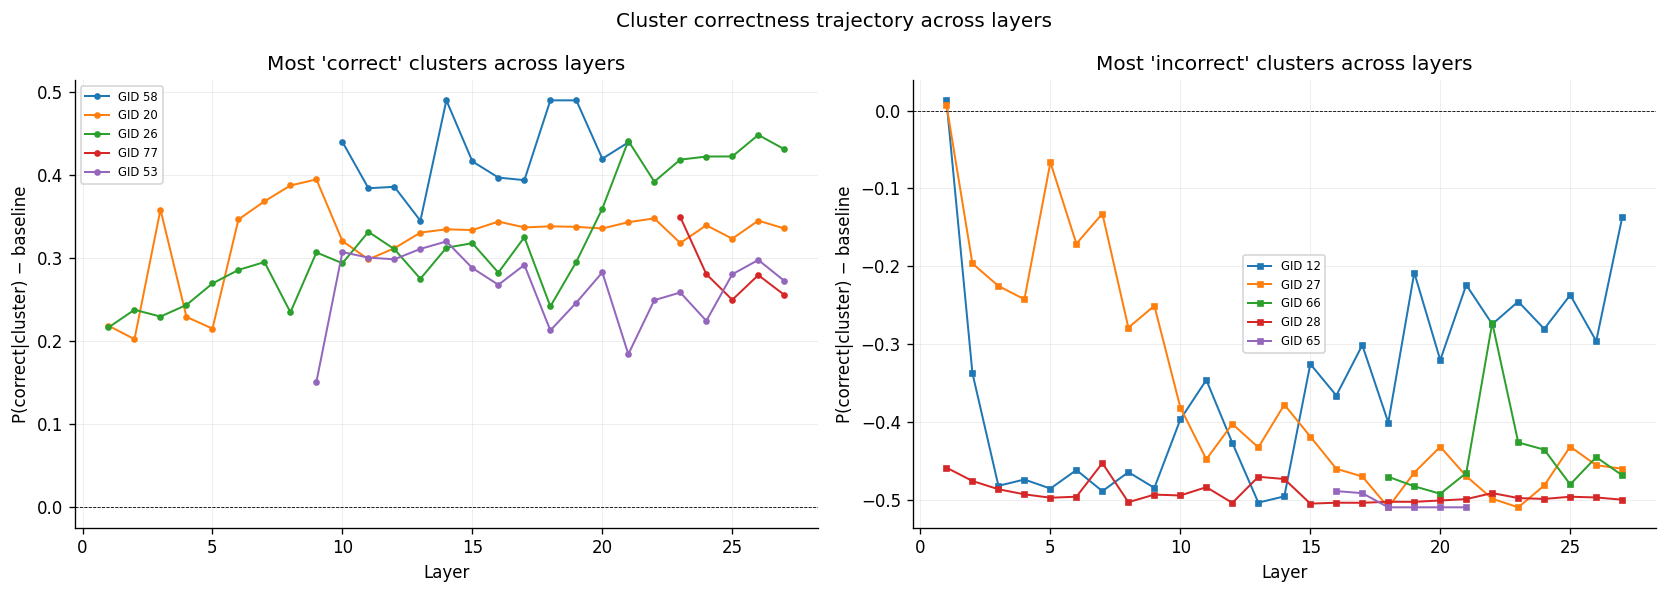

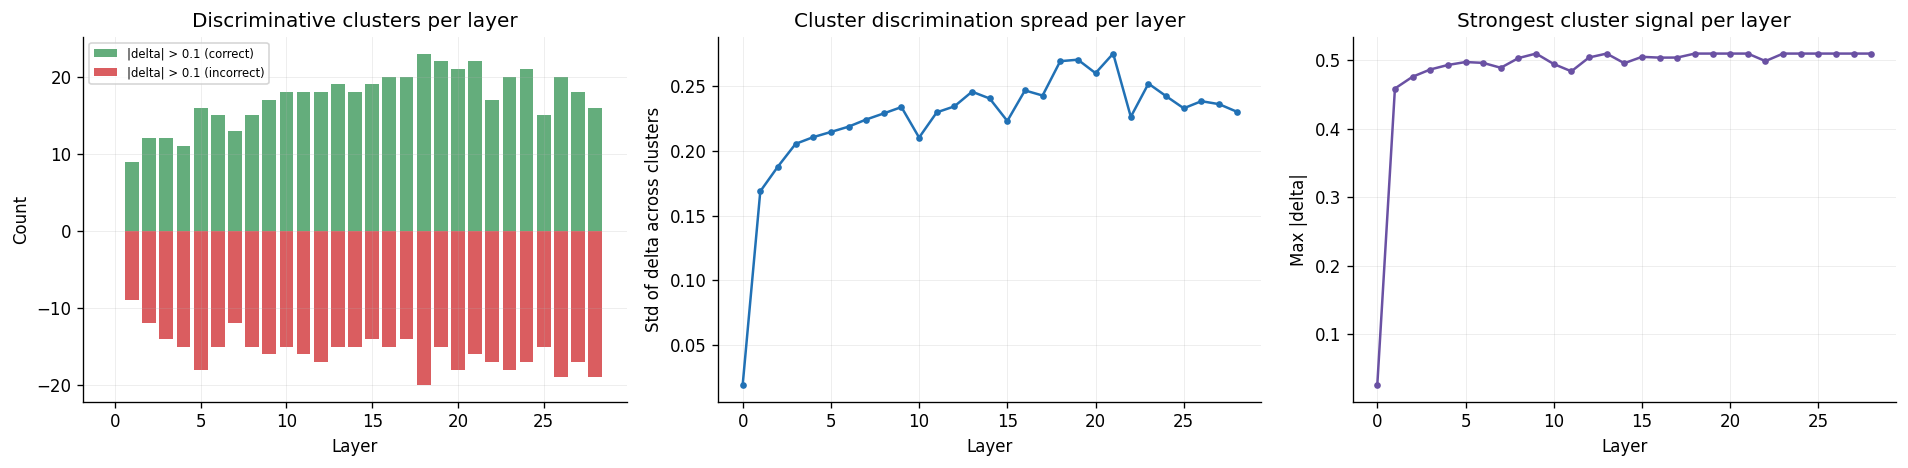

In [38]:
# Per-layer, per-cluster correctness — full table
all_records = []
for li in range(len(_layers)):
    col = _gl[:, li]
    for gid in np.unique(col[col >= 0]):
        mask = col == gid
        n = int(mask.sum())
        if n < 10:
            continue
        rate = float(_y[mask].mean())
        all_records.append({
            "layer": _layers[li],
            "gid": int(gid),
            "n": n,
            "pos_rate": rate,
            "delta": rate - float(_y.mean()),
        })

cluster_df = pd.DataFrame(all_records)
print(f"Total rows: {len(cluster_df)}")
display(cluster_df.head(20))

# ===== Visualization 1: heatmap (layer × cluster) =====
n_global = int(_gl.max()) + 1
delta_mat = np.full((len(_layers), n_global), np.nan)
count_mat = np.zeros((len(_layers), n_global), dtype=np.int64)

baseline = float(_y.mean())
for li in range(len(_layers)):
    col = _gl[:, li]
    for gid in range(n_global):
        mask = col == gid
        c = int(mask.sum())
        if c < 10:
            continue
        count_mat[li, gid] = c
        delta_mat[li, gid] = float(_y[mask].mean()) - baseline

# Only show clusters that are active in at least 3 layers
active_layers_per_gid = np.sum(count_mat > 0, axis=0)
keep_gids = np.where(active_layers_per_gid >= 3)[0]

# Sort by mean delta
mean_delta = np.nanmean(delta_mat[:, keep_gids], axis=0)
order = keep_gids[np.argsort(-mean_delta)]

sub = delta_mat[:, order]
finite = sub[np.isfinite(sub)]
vmax = max(float(np.nanmax(np.abs(finite))), 0.01)

fig, ax = plt.subplots(figsize=(max(10, len(order) * 0.3), 6))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
im = ax.imshow(sub, cmap="RdBu_r", norm=norm, aspect="auto", interpolation="nearest")

step_x = max(1, len(order) // 20)
ax.set_xticks(range(0, len(order), step_x))
ax.set_xticklabels([str(order[i]) for i in range(0, len(order), step_x)],
                   rotation=45, ha="right", fontsize=7)
step_y = max(1, len(_layers) // 15)
ax.set_yticks(range(0, len(_layers), step_y))
ax.set_yticklabels([str(_layers[i]) for i in range(0, len(_layers), step_y)], fontsize=7)
ax.set_xlabel("Global Cluster ID (sorted: correct → incorrect)")
ax.set_ylabel("Layer")

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("P(correct|cluster) − baseline", fontsize=9)
ax.set_title("raw sample_mean — per-layer per-cluster correctness delta")
plt.tight_layout()
plt.show()

# ===== Visualization 2: track individual clusters across layers =====
# Pick the most extreme clusters
extreme_pos = order[:5]   # top 5 most "correct"
extreme_neg = order[-5:]  # top 5 most "incorrect"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for gid in extreme_pos:
    vals = delta_mat[:, gid]
    valid = np.isfinite(vals)
    if valid.sum() < 2:
        continue
    ax.plot(np.array(_layers)[valid], vals[valid],
            marker="o", ms=3, lw=1.2, label=f"GID {gid}")
ax.axhline(0, color="black", ls="--", lw=0.5)
ax.set_xlabel("Layer")
ax.set_ylabel("P(correct|cluster) − baseline")
ax.set_title("Most 'correct' clusters across layers")
ax.legend(fontsize=7)

ax = axes[1]
for gid in extreme_neg:
    vals = delta_mat[:, gid]
    valid = np.isfinite(vals)
    if valid.sum() < 2:
        continue
    ax.plot(np.array(_layers)[valid], vals[valid],
            marker="s", ms=3, lw=1.2, label=f"GID {gid}")
ax.axhline(0, color="black", ls="--", lw=0.5)
ax.set_xlabel("Layer")
ax.set_ylabel("P(correct|cluster) − baseline")
ax.set_title("Most 'incorrect' clusters across layers")
ax.legend(fontsize=7)

plt.suptitle("Cluster correctness trajectory across layers", fontsize=12)
plt.tight_layout()
plt.show()

# ===== Visualization 3: per-layer summary stats =====
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# How many "discriminative" clusters per layer
layer_stats = []
for li in range(len(_layers)):
    deltas = delta_mat[li, :]
    valid = deltas[np.isfinite(deltas)]
    n_strong_pos = int(np.sum(valid > 0.1))
    n_strong_neg = int(np.sum(valid < -0.1))
    spread = float(np.nanstd(valid)) if len(valid) > 0 else 0
    max_delta = float(np.nanmax(np.abs(valid))) if len(valid) > 0 else 0
    layer_stats.append({
        "layer": _layers[li],
        "n_strong_pos": n_strong_pos,
        "n_strong_neg": n_strong_neg,
        "delta_spread": spread,
        "max_abs_delta": max_delta,
    })
ls_df = pd.DataFrame(layer_stats)

ax = axes[0]
ax.bar(ls_df["layer"], ls_df["n_strong_pos"], color=COLORS["green"],
       alpha=0.7, label="|delta| > 0.1 (correct)")
ax.bar(ls_df["layer"], -ls_df["n_strong_neg"], color=COLORS["red"],
       alpha=0.7, label="|delta| > 0.1 (incorrect)")
ax.set_xlabel("Layer")
ax.set_ylabel("Count")
ax.set_title("Discriminative clusters per layer")
ax.legend(fontsize=7)

ax = axes[1]
ax.plot(ls_df["layer"], ls_df["delta_spread"], marker="o", ms=3, color=COLORS["blue"])
ax.set_xlabel("Layer")
ax.set_ylabel("Std of delta across clusters")
ax.set_title("Cluster discrimination spread per layer")

ax = axes[2]
ax.plot(ls_df["layer"], ls_df["max_abs_delta"], marker="o", ms=3, color=COLORS["purple"])
ax.set_xlabel("Layer")
ax.set_ylabel("Max |delta|")
ax.set_title("Strongest cluster signal per layer")

plt.tight_layout()
plt.show()

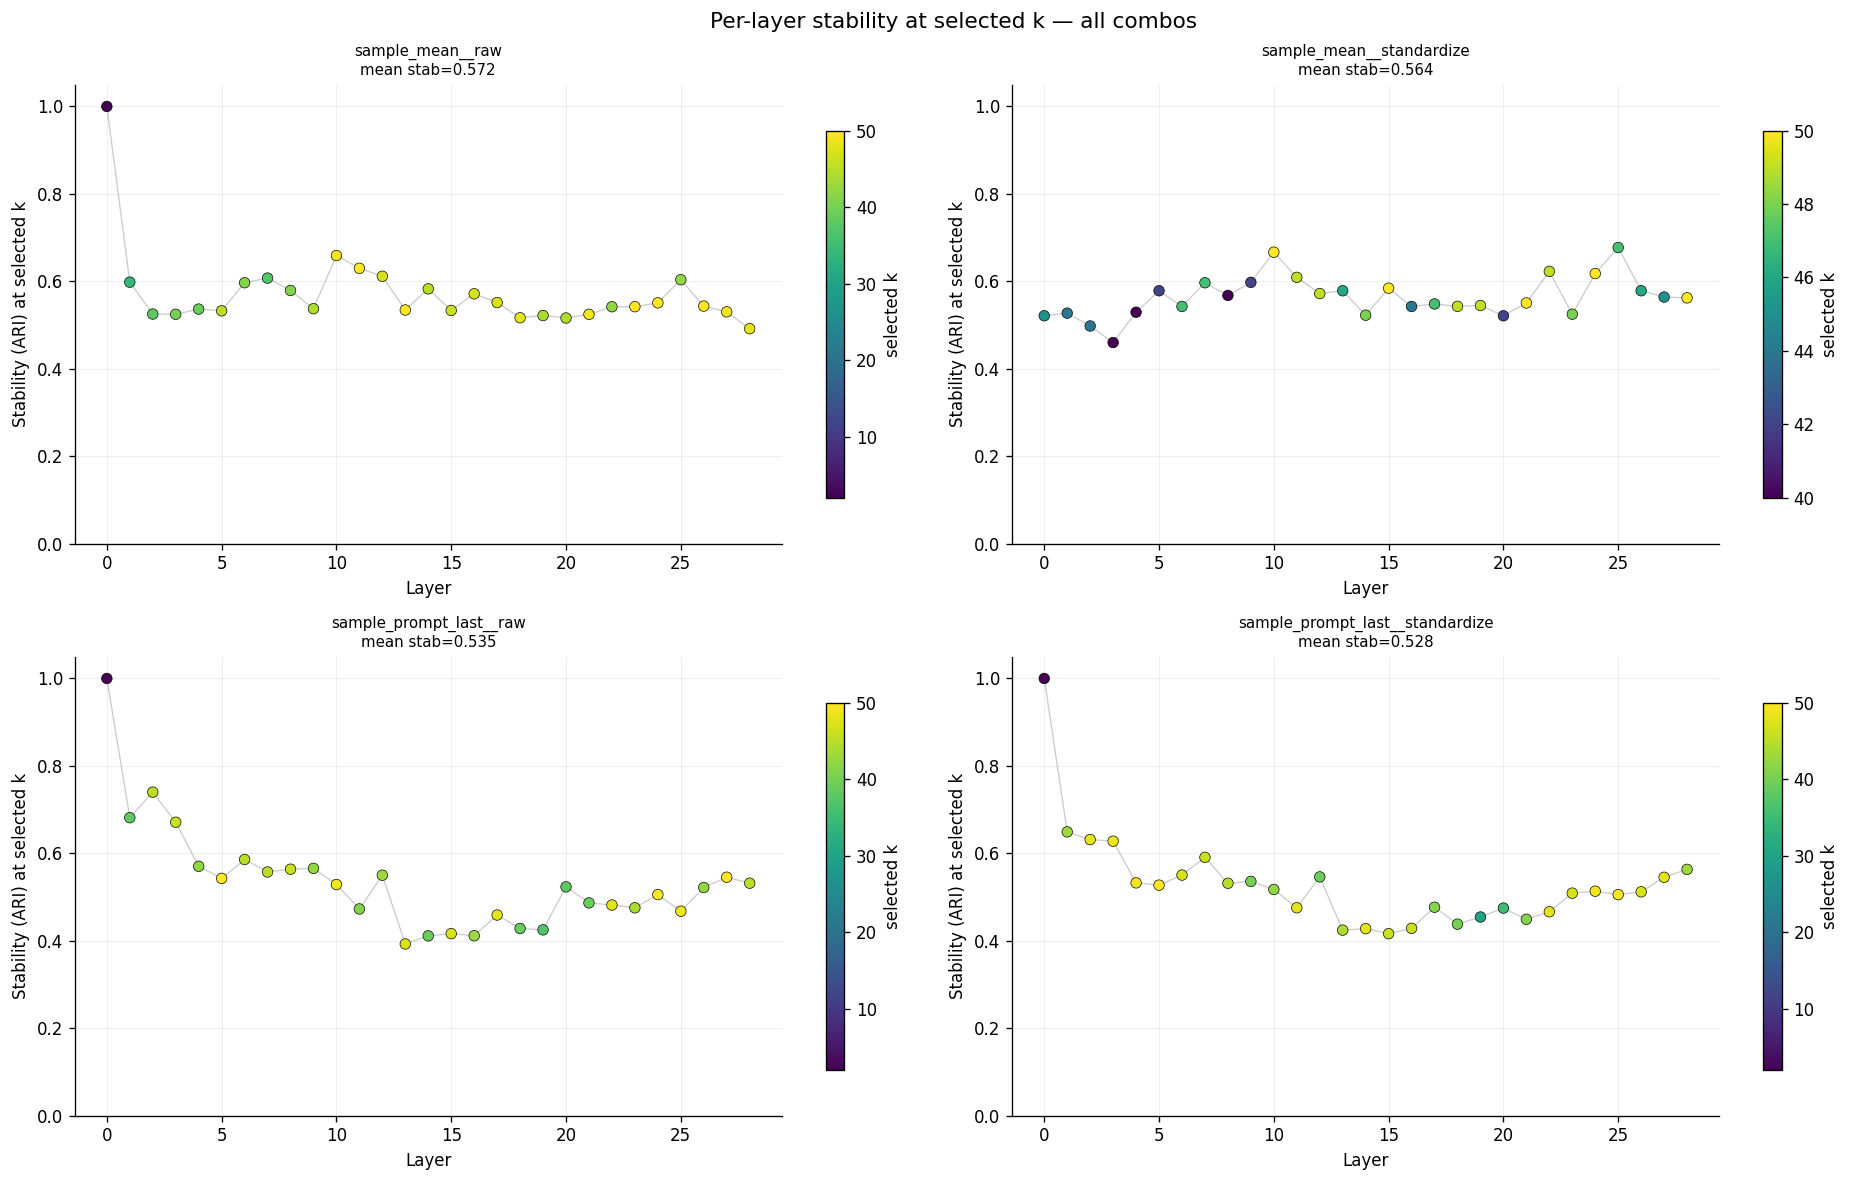

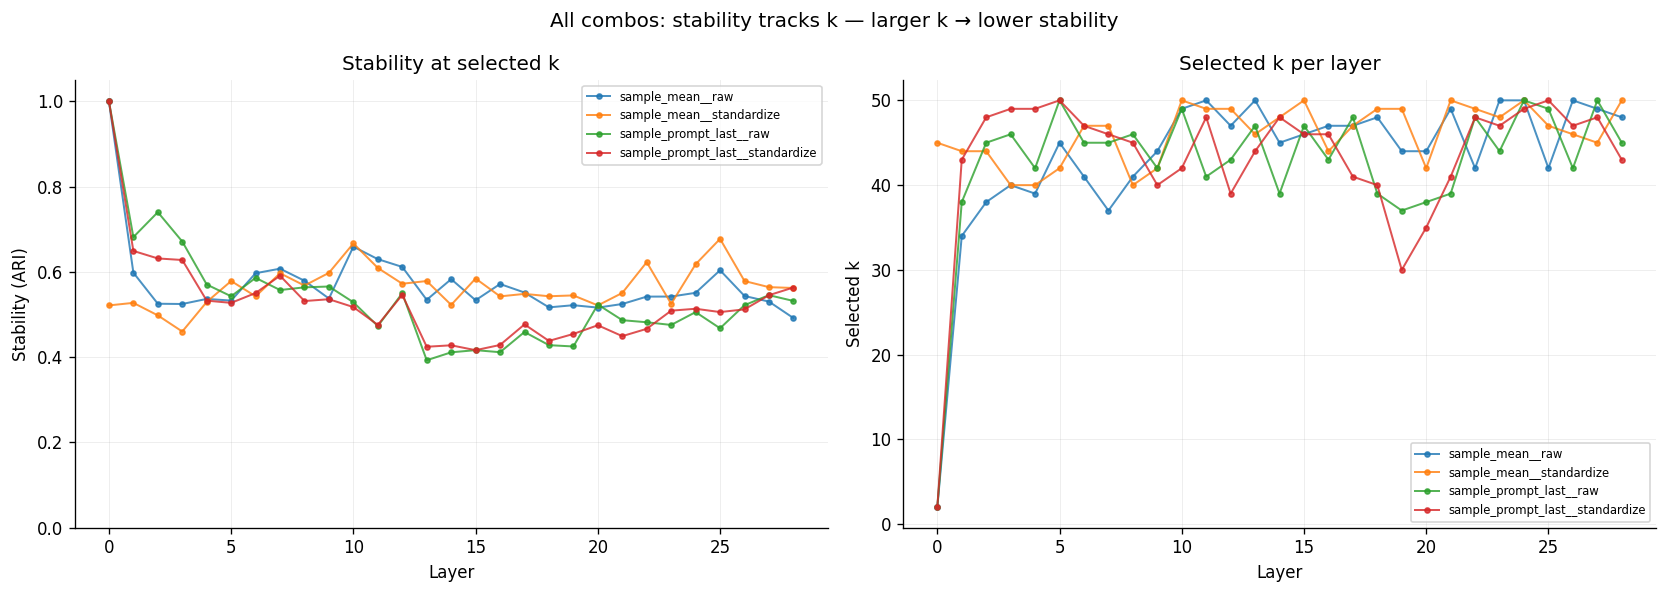

In [39]:
# Per-layer stability: for each layer, at its SELECTED k, how stable is it?

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (combo_key, combo_dir) in enumerate(COMBO_DIRS.items()):
    ax = axes[idx]
    _ws = Workspace(combo_dir, quiet=True, thread_limit=1)
    _scan = _ws.load_scan("scan")
    _select = _ws.load_select("select")
    _metrics = _scan.metrics_df.copy()
    _k_map = _select.k_map

    # For each layer, get stability at the selected k
    layers_sorted = sorted(_k_map.keys())
    stab_at_selected_k = []
    k_selected = []
    for layer in layers_sorted:
        k = _k_map[layer]
        row = _metrics[(_metrics["layer"] == layer) & (_metrics["k"] == k)]
        if len(row) > 0 and "stability" in row.columns:
            stab_at_selected_k.append(float(row["stability"].iloc[0]))
        else:
            stab_at_selected_k.append(np.nan)
        k_selected.append(k)

    # Plot: stability per layer, colored by k
    sc = ax.scatter(layers_sorted, stab_at_selected_k, c=k_selected,
                    cmap="viridis", s=40, edgecolors="black", linewidths=0.4, zorder=3)
    ax.plot(layers_sorted, stab_at_selected_k, color="gray", alpha=0.4, lw=0.8)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Stability (ARI) at selected k")
    ax.set_title(f"{combo_key}\nmean stab={np.nanmean(stab_at_selected_k):.3f}", fontsize=9)
    ax.set_ylim(0, 1.05)
    plt.colorbar(sc, ax=ax, label="selected k", shrink=0.8)

plt.suptitle("Per-layer stability at selected k — all combos", fontsize=13)
plt.tight_layout()
plt.show()

# ===== Direct comparison on same axes =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: stability at selected k per layer
ax = axes[0]
for combo_key, combo_dir in COMBO_DIRS.items():
    _ws = Workspace(combo_dir, quiet=True, thread_limit=1)
    _scan = _ws.load_scan("scan")
    _select = _ws.load_select("select")
    _metrics = _scan.metrics_df.copy()
    _k_map = _select.k_map

    layers_sorted = sorted(_k_map.keys())
    stab = []
    for layer in layers_sorted:
        k = _k_map[layer]
        row = _metrics[(_metrics["layer"] == layer) & (_metrics["k"] == k)]
        stab.append(float(row["stability"].iloc[0]) if len(row) > 0 else np.nan)

    ax.plot(layers_sorted, stab, marker="o", ms=3, lw=1.2, label=combo_key, alpha=0.8)

ax.set_xlabel("Layer")
ax.set_ylabel("Stability (ARI)")
ax.set_title("Stability at selected k")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=7)

# Panel 2: selected k per layer (to contextualize stability)
ax = axes[1]
for combo_key, combo_dir in COMBO_DIRS.items():
    _ws = Workspace(combo_dir, quiet=True, thread_limit=1)
    _select = _ws.load_select("select")
    _k_map = _select.k_map
    layers_sorted = sorted(_k_map.keys())
    ax.plot(layers_sorted, [_k_map[l] for l in layers_sorted],
            marker="o", ms=3, lw=1.2, label=combo_key, alpha=0.8)

ax.set_xlabel("Layer")
ax.set_ylabel("Selected k")
ax.set_title("Selected k per layer")
ax.legend(fontsize=7)

plt.suptitle("All combos: stability tracks k — larger k → lower stability", fontsize=12)
plt.tight_layout()
plt.show()

# ===== Summary table =====
summary_records = []
for combo_key, combo_dir in COMBO_DIRS.items():
    _ws = Workspace(combo_dir, quiet=True, thread_limit=1)
    _scan = _ws.load_scan("scan")
    _select = _ws.load_select("select")
    _metrics = _scan.metrics_df.copy()
    _k_map = _select.k_map

    stab_vals = []
    for layer in sorted(_k_map.keys()):
        k = _k_map[layer]
        row = _metrics[(_metrics["layer"] == layer) & (_metrics["k"] == k)]
        if len(row) > 0:
            stab_vals.append(float(row["stability"].iloc[0]))

    ks = list(_k_map.values())
    summary_records.append({
        "combo": combo_key,
        "k_mean": np.mean(ks),
        "k_max": np.max(ks),
        "stab_mean": np.nanmean(stab_vals),
        "stab_min": np.nanmin(stab_vals),
        "n_layers_below_0.5": sum(1 for s in stab_vals if s < 0.5),
    })

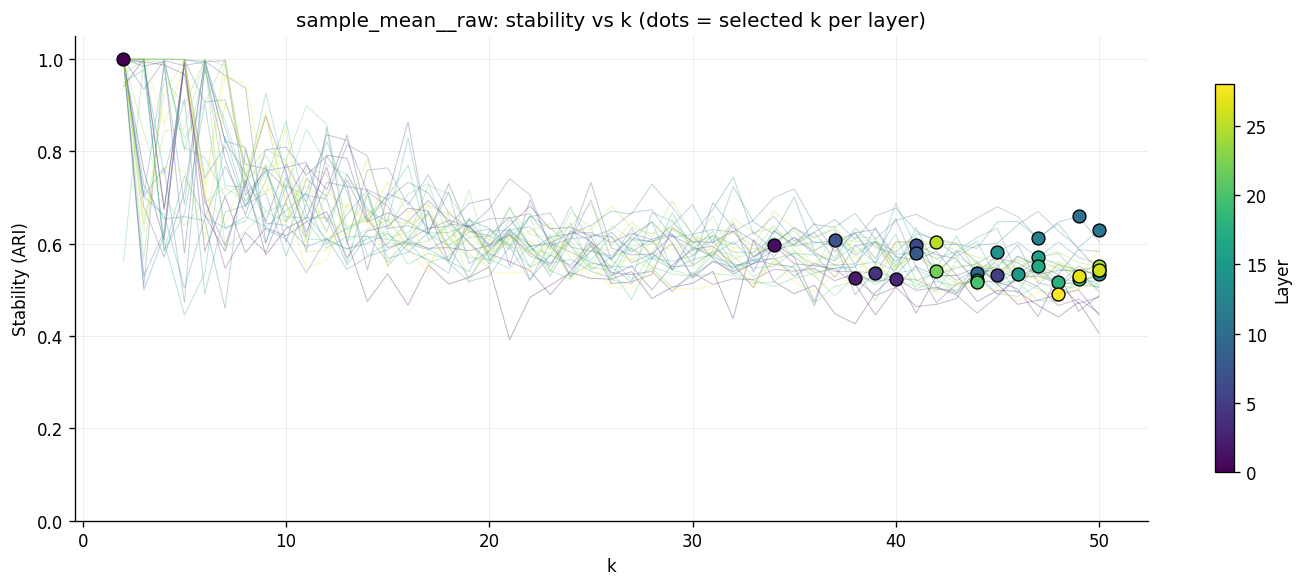

In [40]:
fig, ax = plt.subplots(figsize=(12, 5))

_ws = Workspace(COMBO_DIRS["sample_mean__raw"], quiet=True, thread_limit=1)
_scan = _ws.load_scan("scan")
_select = _ws.load_select("select")
_metrics = _scan.metrics_df
_k_map = _select.k_map

layers_all = sorted(_metrics["layer"].unique())
cmap = plt.cm.viridis
n_layers = len(layers_all)

# All k: thin lines
for i, layer in enumerate(layers_all):
    sub = _metrics[_metrics["layer"] == layer].sort_values("k")
    color = cmap(i / max(1, n_layers - 1))
    ax.plot(sub["k"], sub["stability"], color=color, alpha=0.3, lw=0.6)

# Selected k: big dots
for i, layer in enumerate(layers_all):
    k_sel = _k_map.get(layer)
    if k_sel is None:
        continue
    row = _metrics[(_metrics["layer"] == layer) & (_metrics["k"] == k_sel)]
    if len(row) > 0:
        color = cmap(i / max(1, n_layers - 1))
        ax.scatter(k_sel, row["stability"].iloc[0],
                   color=color, s=60, edgecolors="black", linewidths=0.8, zorder=5)

ax.set_xlabel("k")
ax.set_ylabel("Stability (ARI)")
ax.set_title("sample_mean__raw: stability vs k (dots = selected k per layer)")
ax.set_ylim(0, 1.05)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=Normalize(vmin=min(layers_all), vmax=max(layers_all)))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Layer", shrink=0.8)
plt.tight_layout()
plt.show()

Total components: 1258

Clamped dimension stats:


n_clamped       frac_clamped         min_var
           mean   max         mean     max     min
layer                                             
0          39.0    39       0.0109  0.0109  0.0001
1           0.0     0       0.0000  0.0000  0.0001
2          94.0  3572       0.0262  0.9967  0.0001
3           0.0     0       0.0000  0.0000  0.0002
4           0.0     0       0.0000  0.0000  0.0003
5           0.0     0       0.0000  0.0000  0.0003
6           0.0     0       0.0000  0.0000  0.0003
7           0.0     0       0.0000  0.0000  0.0004
8           0.0     0       0.0000  0.0000  0.0006
9           0.0     0       0.0000  0.0000  0.0007
10          0.0     0       0.0000  0.0000  0.0004
11          0.0     0       0.0000  0.0000  0.0007
12          0.0     0       0.0000  0.0000  0.0005
13          0.0     0       0.0000  0.0000  0.0008
14          0.0     0       0.0000  0.0000  0.0004
15          0.0     0       0.0000  0.0000  0.0007
16          0.0     0       0.0000  0.0000  0.0006
17          0.0     0       0.0000  0.0000  0.0009
18          0.0     0       0.0000  0.0000  0.0009
19          0.0     0       0.0000  0.0000  0.0012
20          0.0     0       0.0000  0.0000  0.0024
21          0.0     0       0.0000  0.0000  0.0016
22          0.0     0       0.0000  0.0000  0.0022
23          0.0     0       0.0000  0.0000  0.0052
24          0.0     0       0.0000  0.0000  0.0174
25          0.0     0       0.0000  0.0000  0.0271
26          0.0     0       0.0000  0.0000  0.0207
27          0.0     0       0.0000  0.0000  0.0129
28          0.0     0       0.0000  0.0000  0.0195

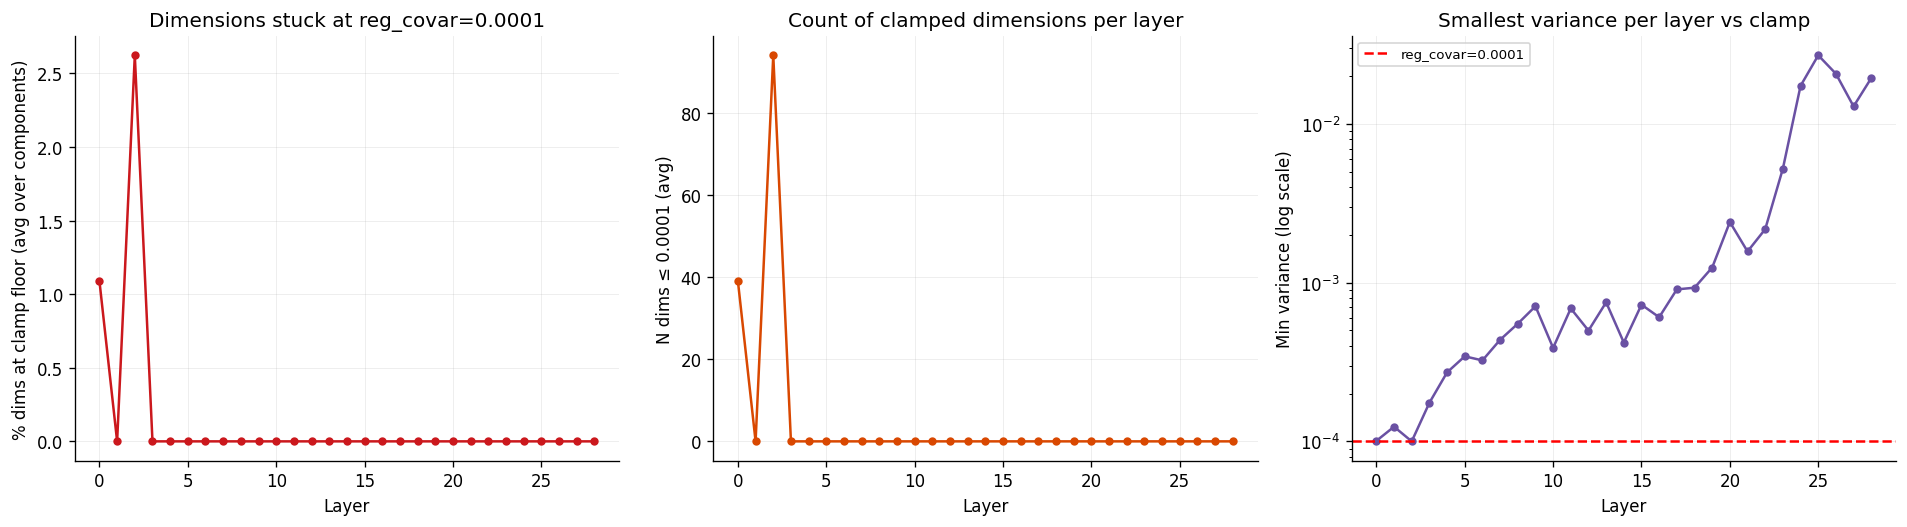

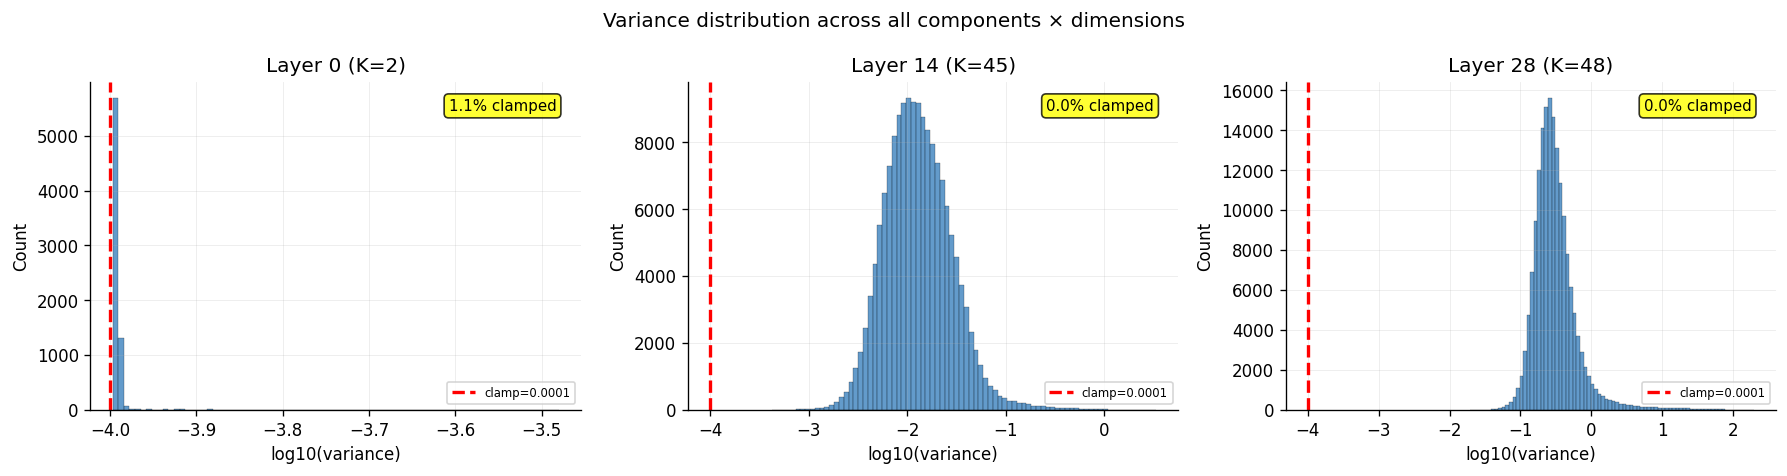


===== Soft probability analysis =====


,layer,ent_mean,ent_median,max_prob_mean,max_prob_below_0.5,max_prob_below_0.8,gap_mean
0,0,0.063,0.0,0.981,0.0,3.608,0.963
1,1,0.001,0.0,1.000,0.0,0.061,0.999
2,2,0.000,0.0,1.000,0.0,0.000,1.000
3,3,0.000,0.0,1.000,0.0,0.000,1.000
4,4,0.000,0.0,1.000,0.0,0.000,1.000
5,5,0.000,0.0,1.000,0.0,0.000,1.000
6,6,0.000,0.0,1.000,0.0,0.000,1.000
7,7,0.000,0.0,1.000,0.0,0.000,1.000
8,8,0.000,0.0,1.000,0.0,0.000,1.000
9,9,0.000,0.0,1.000,0.0,0.000,1.000


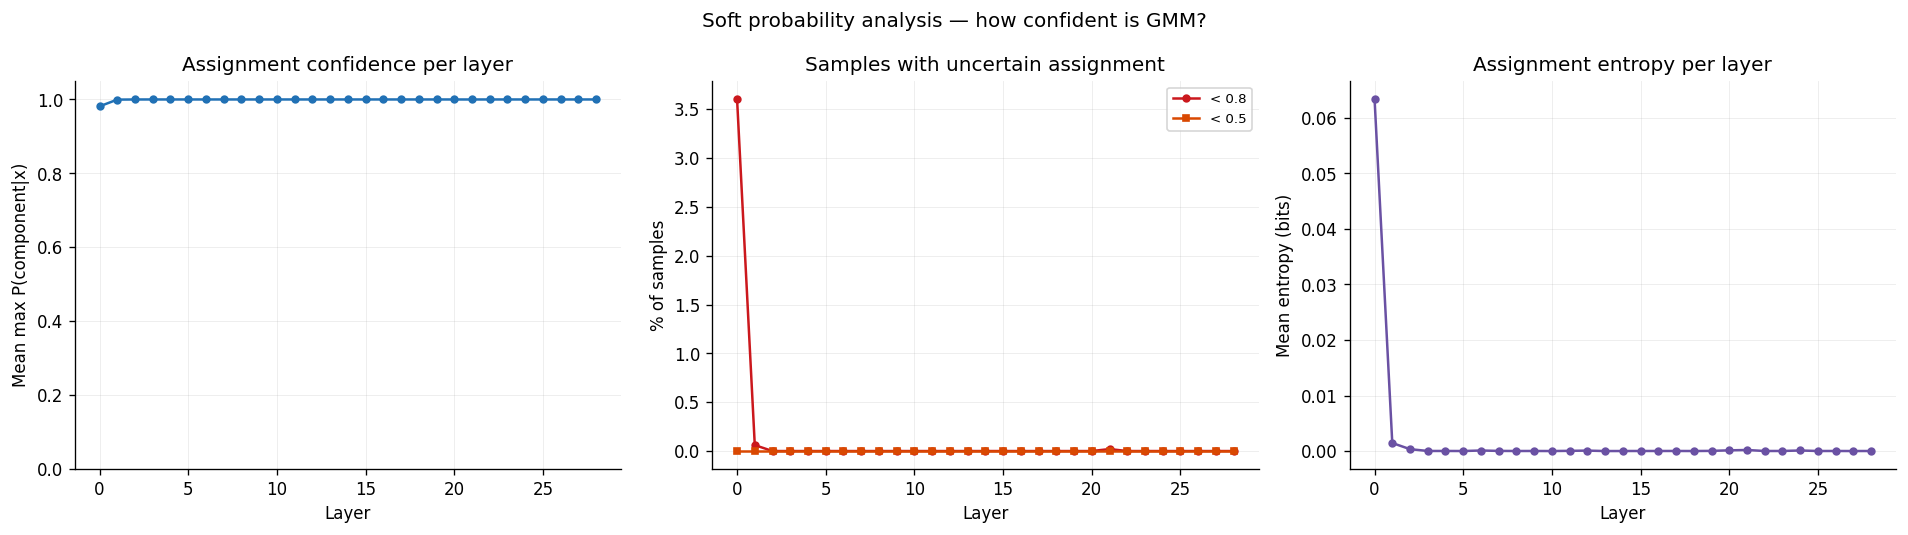

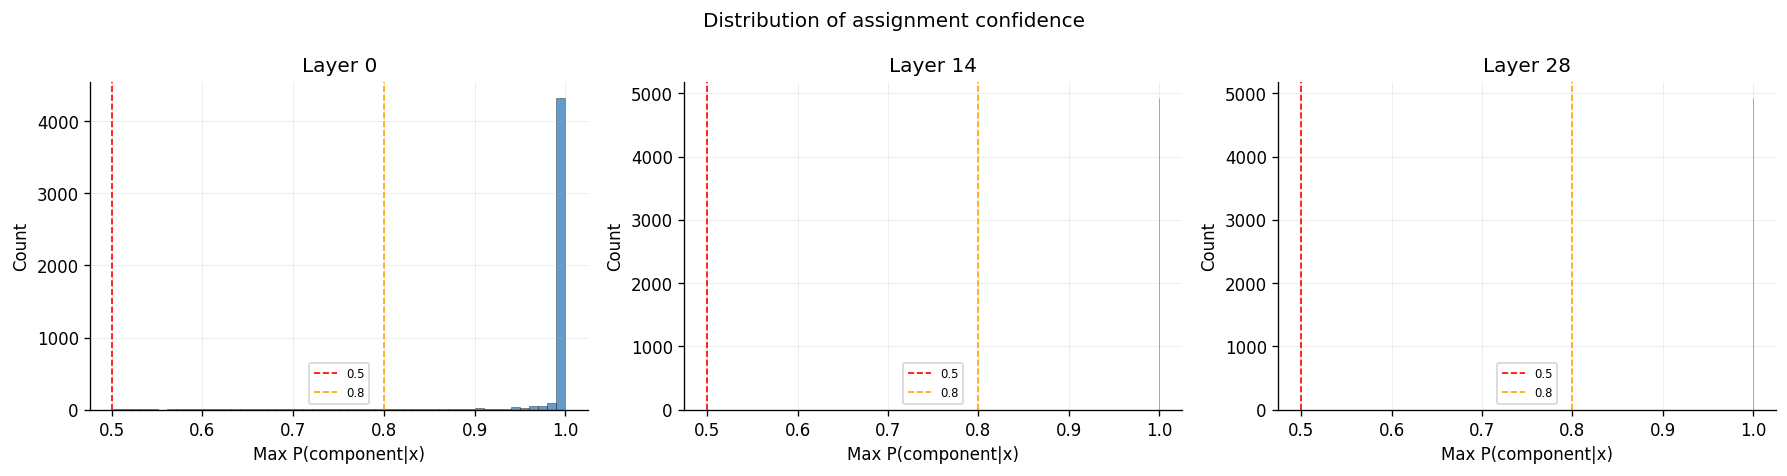

In [41]:
# Load persisted models and inspect covariances + soft probabilities

from hss.storage import ArtifactStore

_ws = Workspace(COMBO_DIRS["sample_mean__raw"], quiet=True, thread_limit=1)
_disc = _ws.load_discretize("discretize")
_gl = np.asarray(_disc.global_labels)

hss_store = ArtifactStore(
    _ws.store.artifact_root("discretize", "discretize") / "discretize" / "hss_artifacts"
)
_layers = list(_disc.layers)

# ===== 1. How many dimensions are clamped per layer? =====
REG_COVAR = 1e-4  # your reg_covar setting

clamp_records = []
for layer in _layers:
    chain, model = hss_store.load_layer_model(layer)
    if not hasattr(model, "covariances_"):
        continue
    covs = np.asarray(model.covariances_)  # [K, D] for diag
    if covs.ndim != 2:
        continue
    K, D = covs.shape
    for c in range(K):
        n_clamped = int(np.sum(covs[c] <= REG_COVAR * 1.01))  # within 1% of clamp
        frac_clamped = n_clamped / D
        min_var = float(covs[c].min())
        median_var = float(np.median(covs[c]))
        clamp_records.append({
            "layer": layer,
            "component": c,
            "n_clamped": n_clamped,
            "frac_clamped": frac_clamped,
            "min_var": min_var,
            "median_var": median_var,
        })

clamp_df = pd.DataFrame(clamp_records)
print(f"Total components: {len(clamp_df)}")
print(f"\nClamped dimension stats:")
display(clamp_df.groupby("layer").agg({
    "n_clamped": ["mean", "max"],
    "frac_clamped": ["mean", "max"],
    "min_var": "min",
}).round(4).head(30))

# ===== 2. Per-layer summary: fraction of dims clamped =====
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

layer_agg = clamp_df.groupby("layer").agg({
    "frac_clamped": "mean",
    "n_clamped": "mean",
    "min_var": "min",
}).reset_index()

ax = axes[0]
ax.plot(layer_agg["layer"], layer_agg["frac_clamped"] * 100,
        marker="o", ms=4, color=COLORS["red"])
ax.set_xlabel("Layer")
ax.set_ylabel("% dims at clamp floor (avg over components)")
ax.set_title(f"Dimensions stuck at reg_covar={REG_COVAR}")

ax = axes[1]
ax.plot(layer_agg["layer"], layer_agg["n_clamped"],
        marker="o", ms=4, color=COLORS["orange"])
ax.set_xlabel("Layer")
ax.set_ylabel(f"N dims ≤ {REG_COVAR} (avg)")
ax.set_title("Count of clamped dimensions per layer")

ax = axes[2]
ax.semilogy(layer_agg["layer"], layer_agg["min_var"], marker="o", ms=4, color=COLORS["purple"])
ax.axhline(REG_COVAR, color="red", ls="--", lw=1.5, label=f"reg_covar={REG_COVAR}")
ax.set_xlabel("Layer")
ax.set_ylabel("Min variance (log scale)")
ax.set_title("Smallest variance per layer vs clamp")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ===== 3. Variance distribution for a few layers =====
sample_layers = [_layers[0], _layers[len(_layers)//2], _layers[-1]]
fig, axes = plt.subplots(1, len(sample_layers), figsize=(5 * len(sample_layers), 4))

for i, layer in enumerate(sample_layers):
    ax = axes[i]
    chain, model = hss_store.load_layer_model(layer)
    covs = np.asarray(model.covariances_)
    all_vars = covs.flatten()
    ax.hist(np.log10(all_vars), bins=80, color=COLORS["blue"], alpha=0.7,
            edgecolor="black", lw=0.2)
    ax.axvline(np.log10(REG_COVAR), color="red", ls="--", lw=2,
               label=f"clamp={REG_COVAR}")
    ax.set_xlabel("log10(variance)")
    ax.set_ylabel("Count")
    ax.set_title(f"Layer {layer} (K={covs.shape[0]})")
    ax.legend(fontsize=7)
    pct_below = float(np.mean(all_vars <= REG_COVAR * 1.01)) * 100
    ax.text(0.95, 0.95, f"{pct_below:.1f}% clamped",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="yellow", alpha=0.8))

plt.suptitle("Variance distribution across all components × dimensions", fontsize=12)
plt.tight_layout()
plt.show()

# ===== 4. Soft probabilities: how confident are the assignments? =====
print("\n===== Soft probability analysis =====")

# Load soft labels for a few layers
entropy_records = []
for layer in _layers:
    d = hss_store.layer_dir(layer)
    soft_path = d / "soft_labels.npy"
    if not soft_path.exists():
        continue
    soft = np.load(soft_path, mmap_mode="r")  # [N, K]
    soft = np.asarray(soft, dtype=np.float32)
    
    # Per-sample entropy of soft assignment
    soft_clipped = np.clip(soft, 1e-12, None)
    ent = -np.sum(soft_clipped * np.log2(soft_clipped), axis=1)  # [N]
    
    # Max probability per sample
    max_prob = np.max(soft, axis=1)  # [N]
    
    # Second-highest probability
    sorted_probs = np.sort(soft, axis=1)
    second_prob = sorted_probs[:, -2] if soft.shape[1] > 1 else np.zeros(len(soft))
    
    entropy_records.append({
        "layer": layer,
        "ent_mean": float(ent.mean()),
        "ent_median": float(np.median(ent)),
        "max_prob_mean": float(max_prob.mean()),
        "max_prob_below_0.5": float(np.mean(max_prob < 0.5)) * 100,
        "max_prob_below_0.8": float(np.mean(max_prob < 0.8)) * 100,
        "gap_mean": float((max_prob - second_prob).mean()),
    })

ent_df = pd.DataFrame(entropy_records)
display(ent_df.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.plot(ent_df["layer"], ent_df["max_prob_mean"], marker="o", ms=4, color=COLORS["blue"])
ax.set_xlabel("Layer")
ax.set_ylabel("Mean max P(component|x)")
ax.set_title("Assignment confidence per layer")
ax.set_ylim(0, 1.05)

ax = axes[1]
ax.plot(ent_df["layer"], ent_df["max_prob_below_0.8"],
        marker="o", ms=4, color=COLORS["red"], label="< 0.8")
ax.plot(ent_df["layer"], ent_df["max_prob_below_0.5"],
        marker="s", ms=4, color=COLORS["orange"], label="< 0.5")
ax.set_xlabel("Layer")
ax.set_ylabel("% of samples")
ax.set_title("Samples with uncertain assignment")
ax.legend(fontsize=8)

ax = axes[2]
ax.plot(ent_df["layer"], ent_df["ent_mean"], marker="o", ms=4, color=COLORS["purple"])
ax.set_xlabel("Layer")
ax.set_ylabel("Mean entropy (bits)")
ax.set_title("Assignment entropy per layer")

plt.suptitle("Soft probability analysis — how confident is GMM?", fontsize=12)
plt.tight_layout()
plt.show()

# ===== 5. Soft probs distribution for sample layers =====
fig, axes = plt.subplots(1, len(sample_layers), figsize=(5 * len(sample_layers), 4))

for i, layer in enumerate(sample_layers):
    ax = axes[i]
    d = hss_store.layer_dir(layer)
    soft_path = d / "soft_labels.npy"
    if not soft_path.exists():
        continue
    soft = np.asarray(np.load(soft_path, mmap_mode="r"), dtype=np.float32)
    max_prob = np.max(soft, axis=1)
    ax.hist(max_prob, bins=50, color=COLORS["blue"], alpha=0.7,
            edgecolor="black", lw=0.3)
    ax.axvline(0.5, color="red", ls="--", lw=1, label="0.5")
    ax.axvline(0.8, color="orange", ls="--", lw=1, label="0.8")
    ax.set_xlabel("Max P(component|x)")
    ax.set_ylabel("Count")
    ax.set_title(f"Layer {layer}")
    ax.legend(fontsize=7)

plt.suptitle("Distribution of assignment confidence", fontsize=12)
plt.tight_layout()
plt.show()